<a href="https://colab.research.google.com/github/L-lovat/NeuromatchProject/blob/main/Kopie_von_ProjectECoG_faceshouses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading of Miller ECoG data of faces/houses (+ noise)

includes some visualizations

In [ ]:
# @title Data retrieval
import os, requests

fname = 'faceshouses.npz'
url = "https://osf.io/argh7/download"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

In [ ]:
# @title Install packages (`nilearn`, `nimare`), import `matplotlib` and set defaults
# install packages to visualize brains and electrode locations
!pip install nilearn --quiet
!pip install nimare --quiet

from matplotlib import rcParams
from matplotlib import pyplot as plt
rcParams['figure.figsize'] = [20, 4]
rcParams['font.size'] = 15
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False
rcParams['figure.autolayout'] = True

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 86.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 4.9 MB/s eta 0:00:00


In [ ]:
# @title Data loading
import numpy as np

alldat = np.load(fname, allow_pickle=True)['dat']

# select just one of the recordings here.
dat1 = alldat[1][0]
dat2 = alldat[0][1]



In [ ]:
N_subj, N_exp = alldat.shape
print(N_subj, N_exp)
subjects1 = []
subjects2 = []
for subj in range(N_subj):
  subjects1.append(alldat[subj, 0])
  subjects2.append(alldat[subj, 1])
  print(f"subject {subj} has {alldat[subj, 0].get('locs').shape[0]} electrodes implented")

i=0
for subject in subjects1:
  #print(i)
  for key in subject.keys():
    ln = len(subject[key]) if type(subject[key]) == type([]) else None
    ln = subject[key].shape if ln is None and type(subject[key]) == type(np.array([])) else ln
    #print(f"\t{key} : {type(subject[key])} - {ln}")
  i += 1

i=0
for subject in subjects2:
  #print(i)
  for key in subject.keys():
    ln = len(subject[key]) if type(subject[key]) == type([]) else None
    ln = subject[key].shape if ln is None and type(subject[key]) == type(np.array([])) else ln
    #print(f"\t{key} : {type(subject[key])} - {ln}")
  i += 1

7 2
subject 0 has 41 electrodes implented
subject 1 has 50 electrodes implented
subject 2 has 39 electrodes implented
subject 3 has 60 electrodes implented
subject 4 has 58 electrodes implented
subject 5 has 39 electrodes implented
subject 6 has 58 electrodes implented


0, Counter({'Brodmann area 19': 5, 'Brodmann area 37': 4, 'Brodmann area 20': 3, 'Brodmann area 28': 3, 'Brodmann area 18': 3, 'Brodmann area 10': 2, 'Brodmann area 32': 2, 'Corpus Callosum': 2, 'Amygdala': 2, 'Brodmann area 47': 2, 'Brodmann area 34': 2, 'Brodmann area 38': 2, 'Brodmann area 21': 2, 'Brodmann area 30': 2, 'Brodmann area 36': 2, 'Brodmann area 13': 1, 'Hippocampus': 1, 'Brodmann area 22': 1})
1, Counter({'Brodmann area 11': 15, 'Brodmann area 38': 7, 'Brodmann area 20': 6, 'Brodmann area 10': 4, 'Brodmann area 46': 3, 'Brodmann area 28': 3, 'Brodmann area 18': 3, 'Brodmann area 37': 3, 'Brodmann area 47': 2, 'Brodmann area 19': 2, 'Brodmann area 35': 1, 'Brodmann area 36': 1})
2, Counter({'Brodmann area 22': 11, 'Dentate': 8, 'Brodmann area 40': 5, 'Brodmann area 11': 4, 'Brodmann area 47': 3, 'Brodmann area 28': 2, 'Brodmann area 43': 2, 'Brodmann area 38': 1, 'Brodmann area 36': 1, 'Brodmann area 37': 1, 'Brodmann area 20': 1})
3, Counter({'Caudate Head': 23, 'Brodma

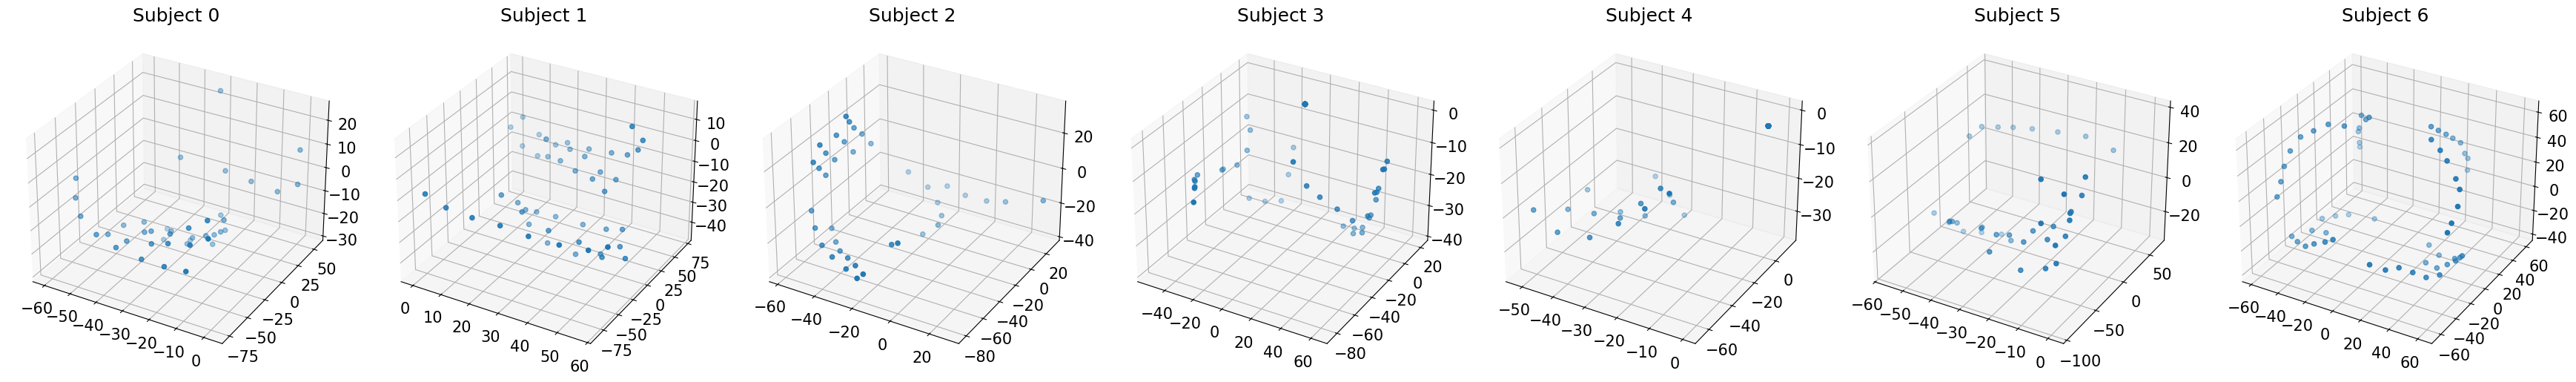

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter


fig = plt.figure(figsize=(5 * len(subjects1), 5))  # Adjust the size as needed

for i, subject in enumerate(subjects1):
    counts = Counter(subject["Brodmann_Area"])
    print(f"{i}, {counts}")
    ax = fig.add_subplot(1, len(subjects1), i + 1, projection='3d')
    ax.scatter(subject["locs"][:, 0], subject["locs"][:, 1], subject["locs"][:, 2])
    ax.set_title(f"Subject {i}")

plt.tight_layout()
plt.show()


# Dataset info #

This is one of multiple ECoG datasets from Miller 2019, recorded in a clinical settings with a variety of tasks. We plan to curate a few more before NMA starts. Raw data here:

https://exhibits.stanford.edu/data/catalog/zk881ps0522

`alldat` contains 7 subjects each with two sessions `dat1` and `dat2`, and was originally used in these publications:

*Miller, Kai J., et al. "Face percept formation in human ventral temporal cortex." Journal of neurophysiology 118.5 (2017): 2614-2627.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

*Miller, Kai J., et al. "The physiology of perception in human temporal lobe is specialized for contextual novelty." Journal of neurophysiology 114.1 (2015): 256-263.*

*Miller, Kai J., et al. "Spontaneous decoding of the timing and content of human object perception from cortical surface recordings reveals complementary information in the event-related potential and broadband spectral change." PLoS computational biology 12.1 (2016): e1004660.*

In this task, subjects in a clinical settings (with ECoG implants) are passively shown faces and house during the first experiment (`dat1`). Then in the second experiment in the same subjects (`dat2`), noise is added to face and houses images and the subject has to detect the faces by pressing a key. Two of the subjects don't have keypresses.

Sample rate is always 1000Hz, and the ECoG data has been notch-filtered at 60, 120, 180, 240 and 250Hz, followed by z-scoring across time and conversion to float16 to minimize size.

Experiment 1:
* `dat1['V']`: continuous voltage data (time by channels)
* `dat1['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat1['t_on']`: time of stimulus onset in data samples
* `dat1['t_off']`: time of stimulus offset, always 400 samples after `t_on`
* `dat1['stim_id`]: identity of stimulus from 1-100, with 1-50 being houses and 51-100 being faces
* `dat1['locs`]: 3D electrode positions on the brain surface

Experiment 2:
* `dat2['V`]: continuous voltage data (time by channels)
* `dat2['srate']`: acquisition rate (1000 Hz). All stimulus times are in units of this.  
* `dat2['t_on']`: time of stimulus onset in data samples
* `dat2['t_off']`: time of stimulus offset, always 1000 samples after `t_on`, with no inter-stimulus interval
* `dat2['stim_id`]: identity of stimulus from 1-600 (not really useful, since we don't know which ones are the same house/face)
* `dat2['stim_cat']`: stimulus category (1 = house, 2 = face)
* `dat2['stim_noise']`: percent noise from 0 to 100
* `dat2['key_press']`: when the subject thought the image was a face
* `dat2['categories']`: categories legend (1 = house, 2 = face)
* `dat2['locs`]: 3D electrode positions on the brain surface


[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False  True  True  True
 False False False False False]
Subject 0 :
	Face response : Counter({np.str_('Brodmann area 19'): 1})
	2.44% of channels ([35])
	House response : Counter({np.str_('Brodmann area 18'): 2})
	4.88% of channels ([33 34])


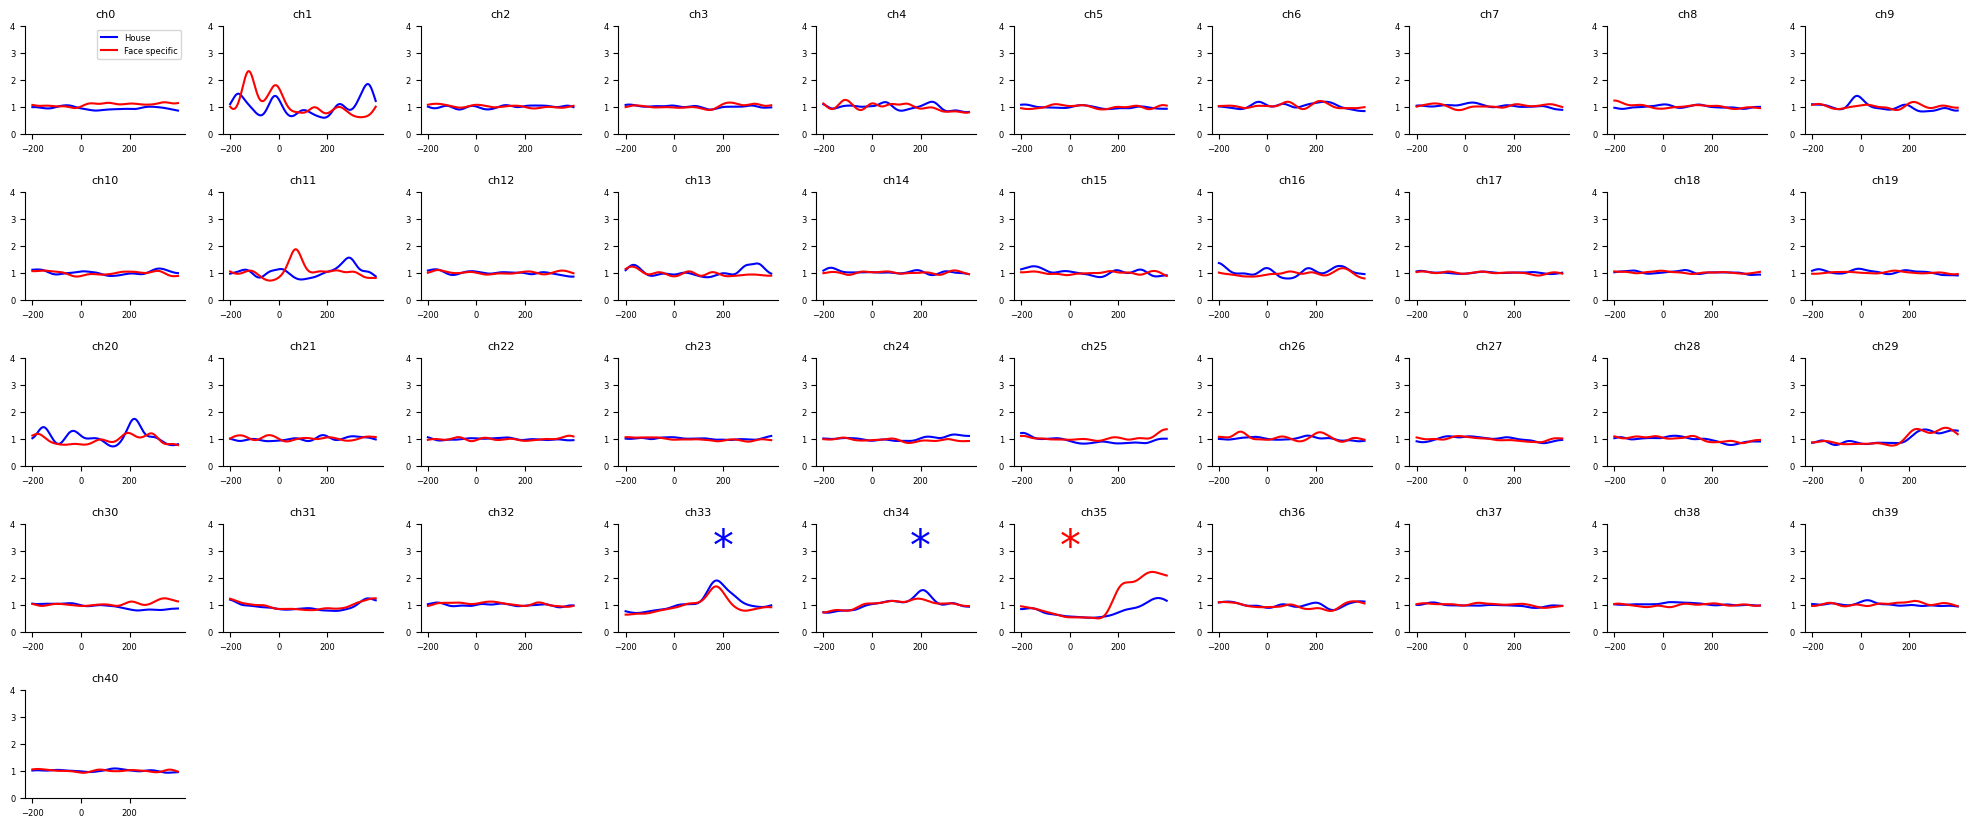

[False False False False False False False False False False False False
 False False False False False False False False  True False False  True
  True False False False False False False False False False False False
 False False False False False False False False False False  True False
 False False False False False False False False False False False False]
Subject 1 :
	Face response : Counter({np.str_('Brodmann area 37'): 1})
	1.67% of channels ([23])
	House response : Counter({np.str_('Brodmann area 19'): 2})
	3.33% of channels ([20 21])


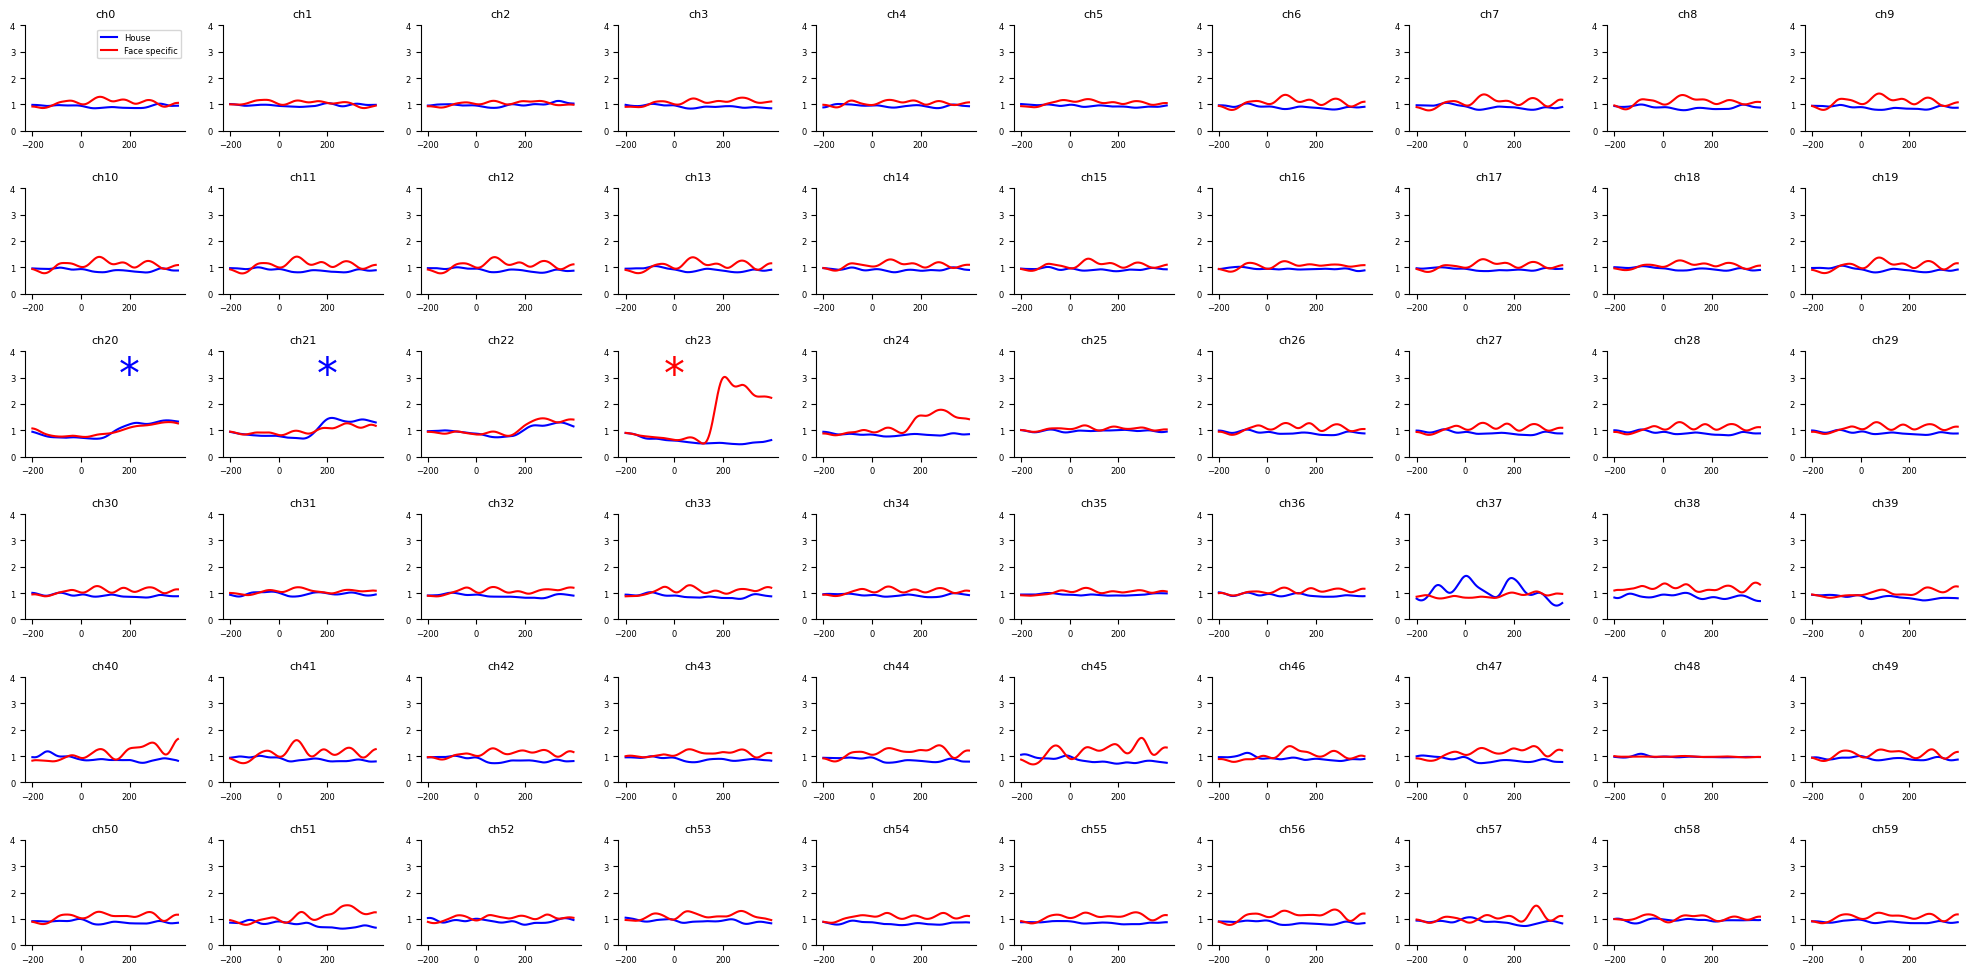

[False False False False False False False False False False False False
 False False False  True False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False]
Subject 2 :
	Face response : Counter({np.str_('Brodmann area 19'): 1})
	1.72% of channels ([15])
	House response : Counter({np.str_('Brodmann area 19'): 1})
	1.72% of channels ([14])


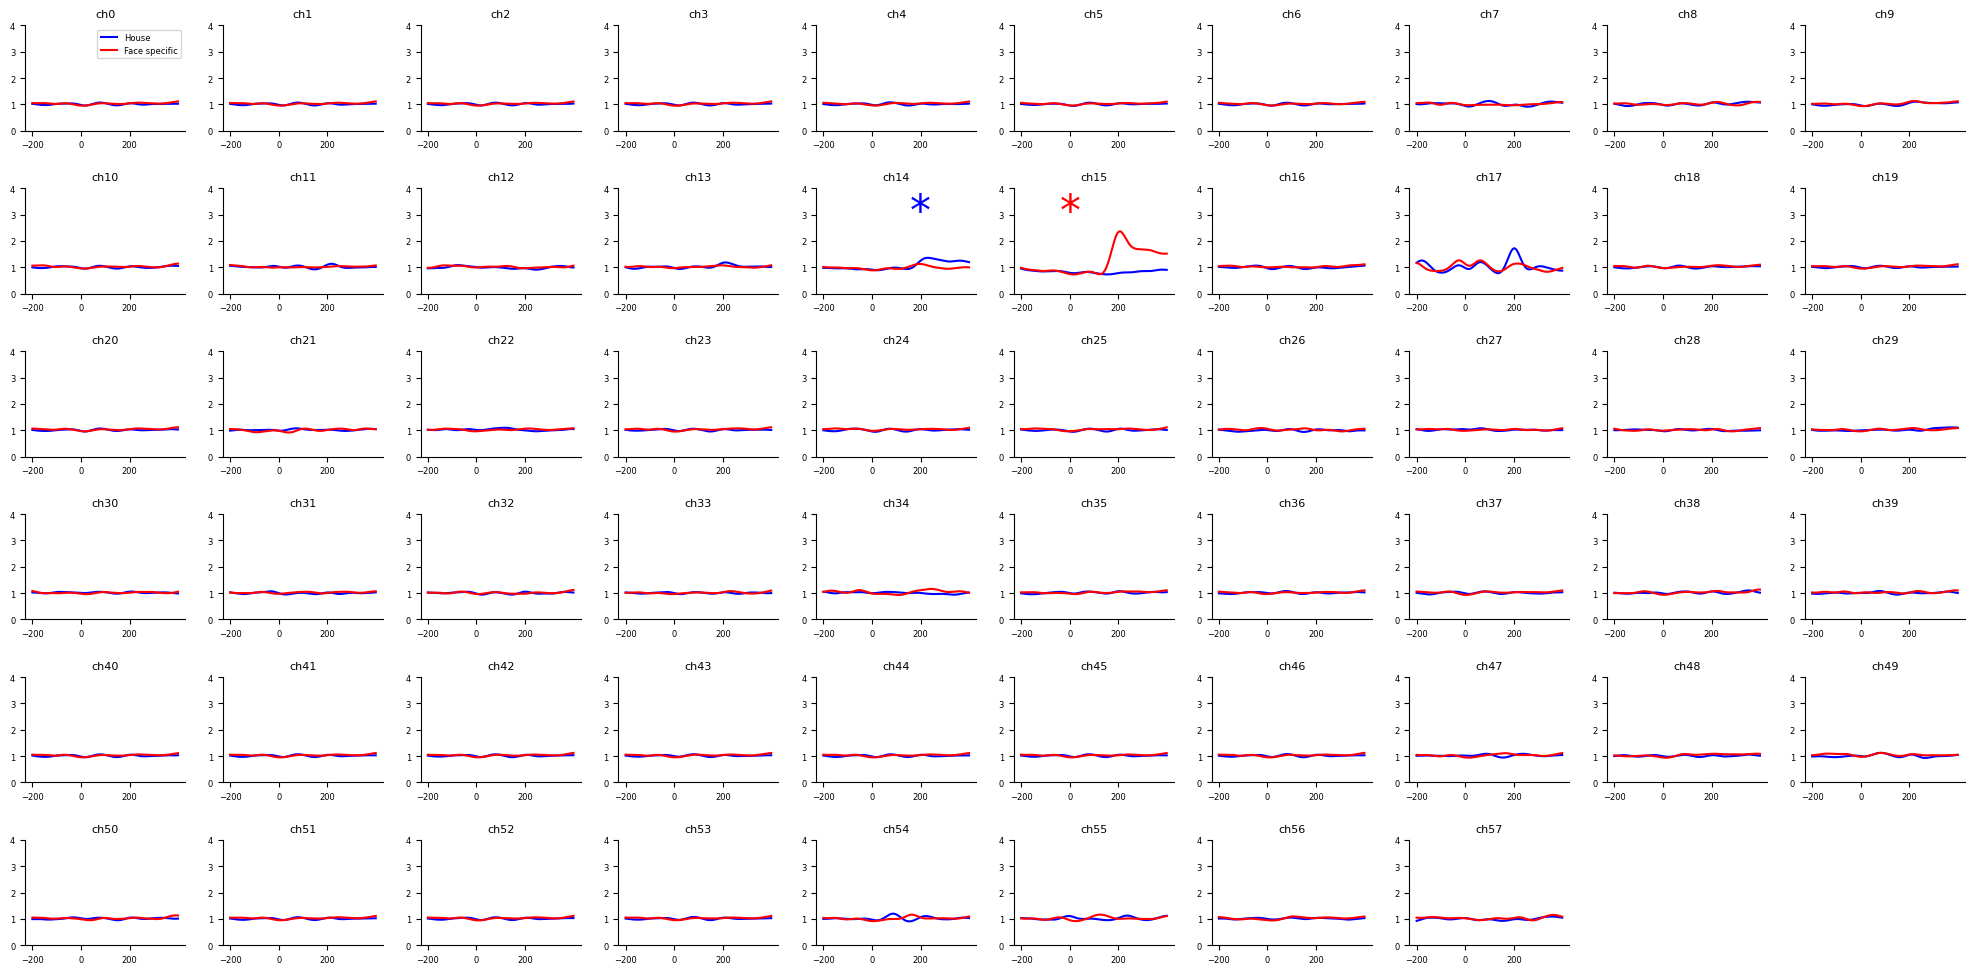

[ True  True  True False  True False False False False False False False
 False False False False False False False False  True False False  True
  True  True  True  True  True False  True False False False  True False
 False False  True]
Subject 3 :
	Face response : Counter({np.str_('Brodmann area 18'): 2, np.str_('Brodmann area 37'): 1, np.str_('Brodmann area 19'): 1})
	10.26% of channels ([23 24 25 30])
	House response : Counter({np.str_('Brodmann area 18'): 5, np.str_('Brodmann area 36'): 1, np.str_('Brodmann area 17'): 1, np.str_('Brodmann area 19'): 1, np.str_('Brodmann area 30'): 1})
	23.08% of channels ([13 24 25 26 27 28 29 30 34])


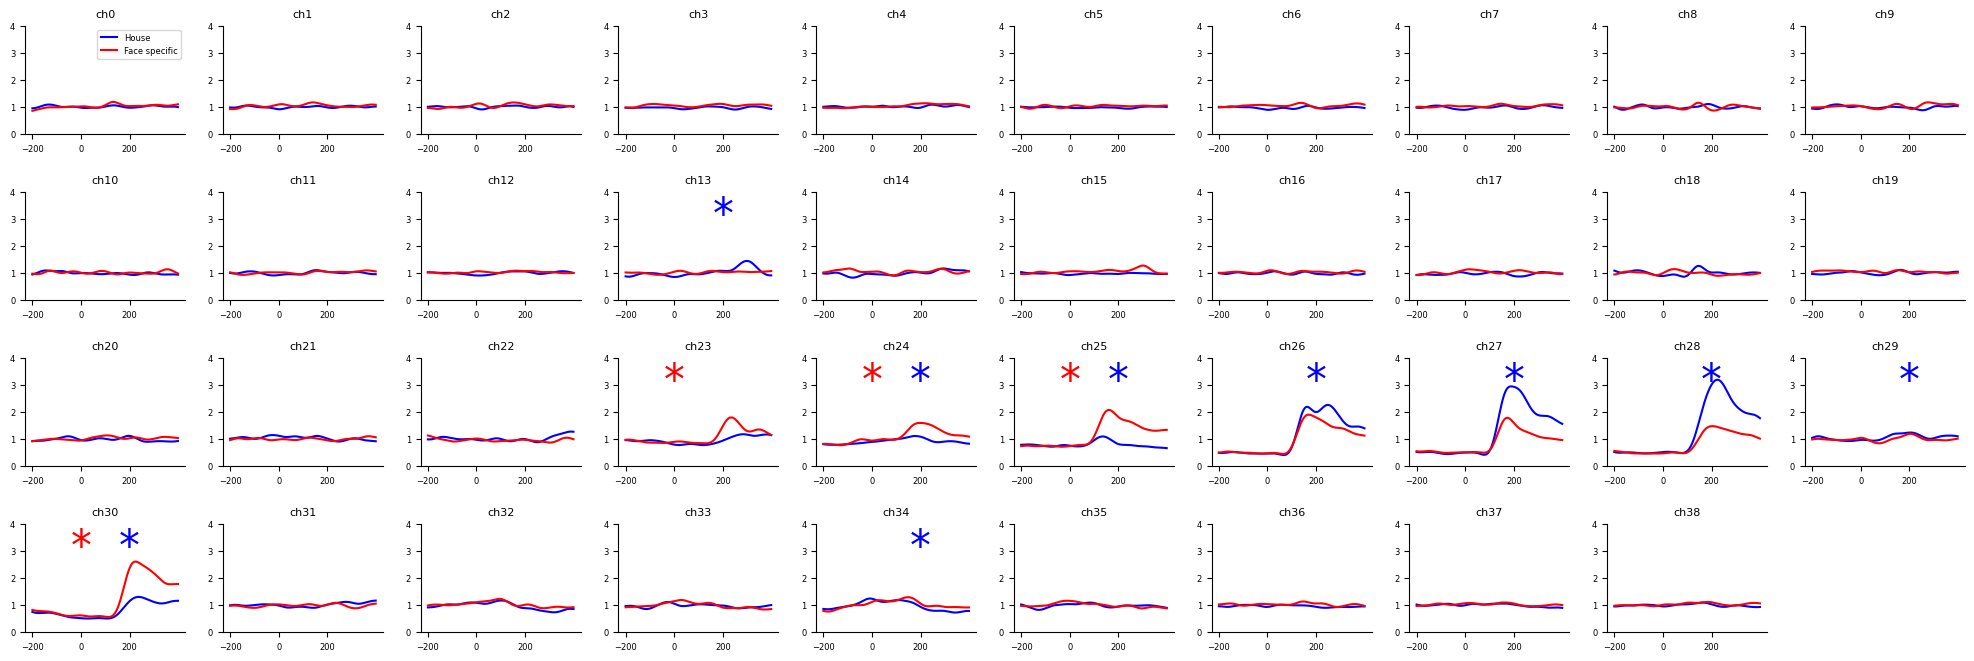

[False False False False False False False False  True False  True False
  True False False  True False False False False False False  True  True
 False False False False False False False False False False False False
  True False  True  True False False False False  True False False False
 False False False False False False False False False False]
Subject 4 :
	Face response : Counter({np.str_('Brodmann area 19'): 2, np.str_('Brodmann area 37'): 2, np.str_('Brodmann area 2'): 1})
	8.62% of channels ([ 8 23 36 38 39])
	House response : Counter({np.str_('Brodmann area 20'): 1, np.str_('Brodmann area 19'): 1})
	3.45% of channels ([ 5 36])


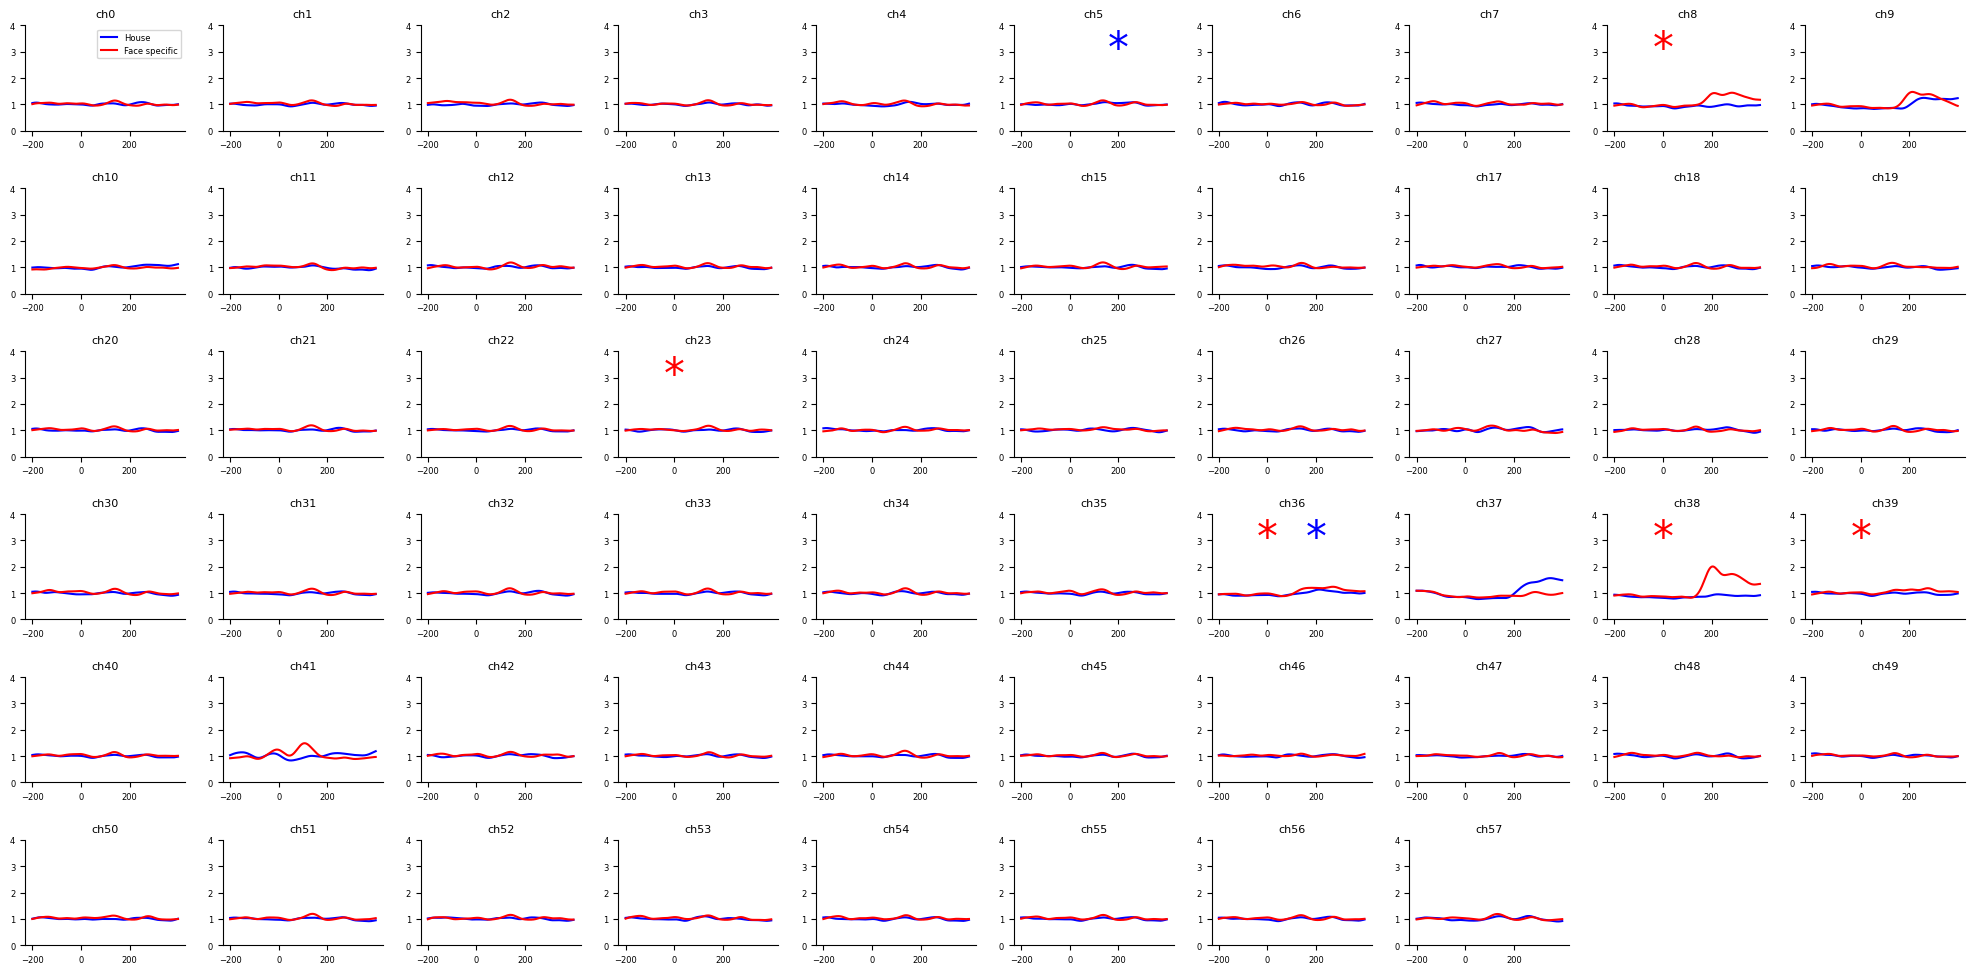

[array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False]), array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False]), array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False, False,
       False, False, False, False, False, False, False, False, F

In [ ]:
from scipy import signal
import numpy as np
from collections import Counter
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, ttest_rel

from scipy.stats import ttest_ind

def paired_permutation_test(pre, post, n_perm=1000):
    """
    H0: post <= pre  vs. H1: post > pre
    pre, post: shape = (n_trials,)
    return p-value
    """
    obs_diff = post.mean() - pre.mean()
    n = len(pre)
    count = 0
    for _ in range(n_perm):
        if_swap = np.random.rand(n) < 0.5
        pre_perm  = np.where(if_swap,  post,   pre)
        post_perm = np.where(if_swap,   pre,   post)
        perm_diff = post_perm.mean() - pre_perm.mean()
        if perm_diff >= obs_diff:
            count += 1
    return (count + 1) / (n_perm + 1)


pval_threshold = 0.03
post_activation_window_min, post_activation_window_max = 100, 200

active_areas_face = []
active_areas_house = []

subjects1_kept = [subjects1[j] for j in [0, 3, 4, 5, 6]]
channels_kept = []

for i, subject in enumerate(subjects1_kept):
    V = subject['V'].astype('float32')

    # Filtering
    b, a = signal.butter(3, [50], btype='high', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)
    V = np.abs(V)**2
    V /= np.mean(V, axis=0)
    b, a = signal.butter(3, [10], btype='low', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    nt, nchan = V.shape
    trange = np.arange(-200, 400)
    ts = subject['t_on'][:, np.newaxis] + trange
    V_epochs = V[ts, :]  # (nstim, 600, nchan)

    pre_idx = slice(0, 200)
    post_idx = slice(post_activation_window_min + 200, post_activation_window_max + 200)

    face_trials = subject['stim_id'] > 50
    house_trials = subject['stim_id'] <= 50

    pre_face = V_epochs[face_trials, pre_idx, :]
    post_face = V_epochs[face_trials, post_idx, :]
    pre_house = V_epochs[house_trials, pre_idx, :]
    post_house = V_epochs[house_trials, post_idx, :]

    pre_face_mean = pre_face.mean(axis=1)
    post_face_mean = post_face.mean(axis=1)
    pre_house_mean = pre_house.mean(axis=1)
    post_house_mean = post_house.mean(axis=1)

    increase_face = np.zeros(nchan, dtype=bool)
    specific_face = np.zeros(nchan, dtype=bool)
    increase_house = np.zeros(nchan, dtype=bool)

    for ch in range(nchan):
        if pre_face_mean.shape[0] > 1:
            pval_perm = paired_permutation_test(pre_face_mean[:, ch], post_face_mean[:, ch], n_perm=2000)

            if post_house_mean.shape[0] > 1:
                pval_unpaired = ttest_ind(post_face_mean[:, ch], post_house_mean[:, ch], alternative='greater').pvalue
            else:
                pval_unpaired = 1.0  # not significant if no data

            increase_face[ch] = (pval_perm < pval_threshold)
            specific_face[ch] = (pval_perm < pval_threshold) and (pval_unpaired < pval_threshold)

        if pre_house_mean.shape[0] > 1:
            pval_house = paired_permutation_test(pre_house_mean[:, ch], post_house_mean[:, ch], n_perm=2000)
            increase_house[ch] = pval_house < pval_threshold

    print(increase_face)
    #channels_kept.append(np.ones(nchan, dtype=bool))  # all channels kept here



    #specific_face = increase_face
    # Get Brodmann areas
    triggered_areas_face = np.array(subject['Brodmann_Area'])[specific_face]

    triggered_areas_house = np.array(subject['Brodmann_Area'])[increase_house]

    counts_face = Counter(triggered_areas_face)
    counts_house = Counter(triggered_areas_house)

    active_areas_face.append(counts_face)
    active_areas_house.append(counts_house)

    channels_kept.append(specific_face)
    #print(specific_face)

    print(f"Subject {i} :")
    print(f"\tFace response : {counts_face}\n\t{len(triggered_areas_face)/nchan:.2%} of channels ({np.arange(nchan)[specific_face]})")
    print(f"\tHouse response : {counts_house}\n\t{len(triggered_areas_house)/nchan:.2%} of channels ({np.arange(nchan)[increase_house]})")


    # Plot average response per channel for faces and houses
    V_house_avg = V_epochs[house_trials].mean(axis=0)  # shape (600, nchan)
    V_face_avg = V_epochs[face_trials].mean(axis=0)

    plt.figure(figsize=(20, 10))
    for j in range(nchan):
        ax = plt.subplot(6, 10, j + 1)
        plt.plot(trange, V_house_avg[:, j], label='House', color="blue")
        plt.plot(trange, V_face_avg[:, j], label='Face specific', color="red")
        plt.title(f'ch{j}', fontsize=8)
        plt.xticks([-200, 0, 200])
        plt.ylim([0, 4])
        plt.tick_params(labelsize=6)

        # Plot asterisks for significance
        if specific_face[j]:
            plt.text(0, 3.9, '*', color='red', fontsize=30, ha='center', va='top')
        if increase_house[j]:
            offset = 0.1 if increase_face[j] else 0  # shift if both
            plt.text(200, 3.9, '*', color='blue', fontsize=30, ha='center', va='top')

        if j == 0:
            plt.legend(fontsize=6)

    plt.tight_layout()
    plt.show()
print(channels_kept)


In [ ]:
N_subj = len(subjects1_kept)
for i in range(N_subj):
  print(active_areas_face[i] )

Counter({np.str_('Brodmann area 19'): 1})
Counter({np.str_('Brodmann area 37'): 1})
Counter({np.str_('Brodmann area 19'): 1})
Counter({np.str_('Brodmann area 18'): 2, np.str_('Brodmann area 37'): 1, np.str_('Brodmann area 19'): 1})
Counter({np.str_('Brodmann area 19'): 2, np.str_('Brodmann area 37'): 2, np.str_('Brodmann area 2'): 1})


In [ ]:

all_areas = []
for subject in subjects1_kept:
  for area in subject['Brodmann_Area']:
    print(area)
    if area not in all_areas:
      all_areas.append(area)
N_areas = len(all_areas)
activation_matrix_face = np.zeros((N_subj, N_areas))
for subject_idx in range(N_subj):
  for area_idx, area in enumerate(all_areas):
    if area in list(active_areas_face[subject_idx].keys()):
      activation_matrix_face[subject_idx, area_idx] = active_areas_face[subject_idx][area]

activation_matrix_house = np.zeros((N_subj, N_areas))
for subject_idx in range(N_subj):
  for area_idx, area in enumerate(all_areas):
    if area in list(active_areas_house[subject_idx].keys()):
      activation_matrix_house[subject_idx, area_idx] = active_areas_house[subject_idx][area]

present_areas_matrix = np.zeros((N_subj, N_areas))
for subject_idx, subject in enumerate(subjects1_kept):
  subject_areas = Counter(subject['Brodmann_Area'])
  print(subject_areas)
  for area_idx, area in enumerate(all_areas):
    if area in list(subject_areas.keys()):
      present_areas_matrix[subject_idx, area_idx] += subject_areas[area]



Brodmann area 10
Brodmann area 10
Brodmann area 32
Brodmann area 32
Corpus Callosum
Corpus Callosum
Brodmann area 13
Brodmann area 20
Brodmann area 20
Hippocampus
Amygdala
Brodmann area 28
Brodmann area 47
Brodmann area 47
Brodmann area 34
Brodmann area 28
Brodmann area 38
Brodmann area 38
Brodmann area 34
Amygdala
Brodmann area 28
Brodmann area 21
Brodmann area 30
Brodmann area 30
Brodmann area 36
Brodmann area 36
Brodmann area 20
Brodmann area 18
Brodmann area 19
Brodmann area 19
Brodmann area 19
Brodmann area 37
Brodmann area 37
Brodmann area 18
Brodmann area 18
Brodmann area 19
Brodmann area 19
Brodmann area 37
Brodmann area 37
Brodmann area 21
Brodmann area 22
Brodmann area 30
Brodmann area 36
Brodmann area 36
Brodmann area 36
Brodmann area 20
Brodmann area 20
Brodmann area 20
Brodmann area 21
Brodmann area 38
Brodmann area 38
Brodmann area 20
Brodmann area 20
Brodmann area 21
Brodmann area 21
Brodmann area 38
Brodmann area 38
Brodmann area 21
Brodmann area 21
Brodmann area 21
Bro

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

def show_activation_matrix(activation_matrix, present_areas_matrix, title="Activation Matrix", width=3):
    fig, ax = plt.subplots(figsize=(len(all_areas) * 0.5 + 4, N_subj * 0.4 + 2))
    print(activation_matrix)
    # Plot activation matrix
    im = ax.imshow(activation_matrix, cmap='viridis', aspect='auto')

    # Overlay red cells with rectangle + cross for non-recorded areas
    for i in range(present_areas_matrix.shape[0]):
        for j in range(present_areas_matrix.shape[1]):
            if present_areas_matrix[i, j] == 0:
                # Red rectangle
                rect = plt.Rectangle((j - 0.5, i - 0.5), 1, 1, linewidth=width,
                                     edgecolor='red', facecolor='none')
                ax.add_patch(rect)

                # Red cross
                ax.plot([j - 0.5, j + 0.5], [i - 0.5, i + 0.5], color='red', linewidth=width / 2)
                ax.plot([j - 0.5, j + 0.5], [i + 0.5, i - 0.5], color='red', linewidth=width / 2)

    print(present_areas_matrix.shape)
    electrodes_per_area = np.sum(present_areas_matrix, axis=0)
    print(electrodes_per_area.shape)

    # Set top x-ticks as area labels (rotated 45°)
    ax.set_xticks(np.arange(len(all_areas)))
    ax.set_xticklabels(all_areas, rotation=45, ha='left')
    ax.xaxis.set_label_position('top')
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

    # Set y-ticks
    ax.set_yticks(np.arange(N_subj))
    ax.set_yticklabels([f"Subj {i}" for i in range(N_subj)])

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Number of\ntriggered electrodes")

    # Add secondary x-axis at the bottom for column sums (rotated 90°)
    ax2 = ax.secondary_xaxis('bottom')
    col_sums = activation_matrix.sum(axis=0)
    ax2.set_xticks(np.arange(len(all_areas)))
    ax2.set_xticklabels([f"{int(s)}/{int(electrodes_per_area[i])}" for i,s in enumerate(col_sums)], rotation=90, va='top')
    ax2.tick_params(top=False, bottom=True, labeltop=False, labelbottom=True)
    ax2.set_xlabel("Sum over subjects")

    # Add title
    plt.title(title + " (Subjects × Brodmann Areas)", pad=20)
    plt.tight_layout()
    plt.show()


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 1. 1. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 2. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 1. 0. 0. 0.]]
(5, 32)
(32,)


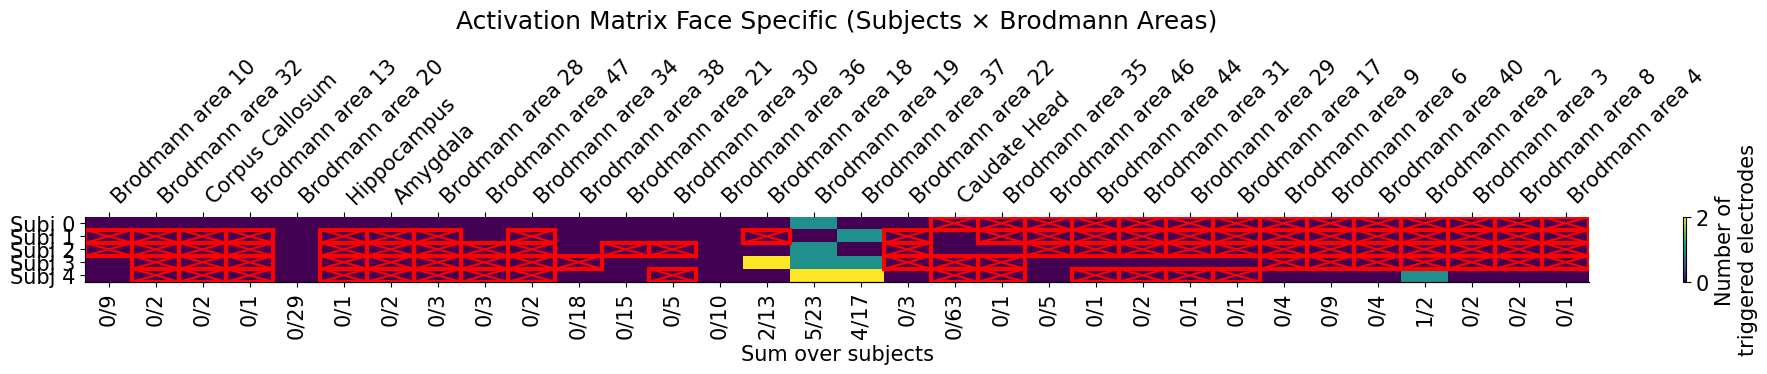

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 5. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]]
(5, 32)
(32,)


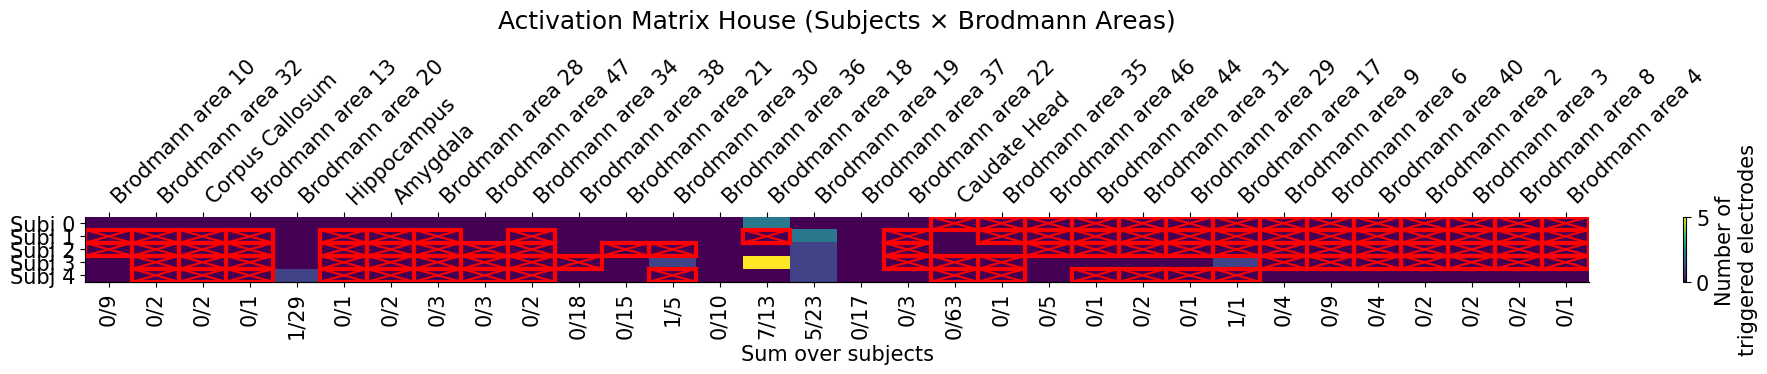

In [ ]:
show_activation_matrix(activation_matrix_face, present_areas_matrix, "Activation Matrix Face Specific")
show_activation_matrix(activation_matrix_house, present_areas_matrix, "Activation Matrix House")

In [ ]:

def paired_permutation_test(pre, post, n_perm=1000):
    """
    H0: post <= pre  vs. H1: post > pre
    pre, post: shape = (n_trials,)
    return p-value
    """
    obs_diff = post.mean() - pre.mean()
    n = len(pre)
    count = 0
    for _ in range(n_perm):
        # 随机决定是否交换每个 trial 的 pre/post
        if_swap = np.random.rand(n) < 0.5
        pre_perm  = np.where(if_swap,  post,   pre)
        post_perm = np.where(if_swap,   pre,   post)
        perm_diff = post_perm.mean() - pre_perm.mean()
        if perm_diff >= obs_diff:
            count += 1
    # +1 修正避免 p=0
    return (count + 1) / (n_perm + 1)

pval_threshold = 0.1
post_activation_window_min, post_activation_window_max = 100, 200
noise_bins = [0, 20, 40, 60, 80, 101]
num_bins = len(noise_bins)-1

active_areas_face = []
active_areas_house = []
subjects2_kept = [subjects2 [j] for j in [0,3,4,5,6]]
for i, subject in enumerate(subjects2_kept):
    V = subject['V'].astype('float32')* subject["scale_uv"]

    # High-pass filter at 50 Hz
    b, a = signal.butter(3, [50], btype='high', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    # Compute power (rectification and squaring)
    V = np.abs(V)**2

    # Normalize over full signal (optional)
    V /= np.mean(V, axis=0)

    # Low-pass filter at 10 Hz
    b, a = signal.butter(3, [10], btype='low', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)
    nt, nchan = V.shape

    all_noise_active_areas_face = []
    all_noise_active_areas_house = []

    for j in range(num_bins):
      lower = noise_bins[j]
      upper = noise_bins[j+1]

      house_trials = (subject['stim_cat'] == 1).flatten() * (subject['stim_noise'].flatten() >= lower) * (subject['stim_noise'].flatten() < upper)
      face_trials = (subject['stim_cat'] == 2).flatten() * (subject['stim_noise'].flatten() >= lower) * (subject['stim_noise'].flatten() < upper)

      print(np.count_nonzero(face_trials))
      # Build epochs around each stimulus onset
      trange = np.arange(-200, 400)  # 600 ms window
      ts = subject['t_on'][:, np.newaxis] + trange
      V_epochs = V[ts, :]  # shape (nstim, 600, nchan)

      # Pre/post slices (indices relative to epoch window)
      pre_idx = slice(0, 200)    # -200 ms to 0 ms
      post_idx = slice(post_activation_window_min + 200, post_activation_window_max + 200) # 0 ms to +400 ms

      # Extract pre and post stimulus data per trial and channel
      pre_face = V_epochs[face_trials, pre_idx, :]   # shape (n_face_trials, 200, nchan)
      post_face = V_epochs[face_trials, post_idx, :] # shape (n_face_trials, 400, nchan)

      pre_house = V_epochs[house_trials, pre_idx, :]
      post_house = V_epochs[house_trials, post_idx, :]

      # Compute mean power over time window, per trial and channel
      pre_face_mean = pre_face.mean(axis=1)   # shape (n_face_trials, nchan)
      post_face_mean = post_face.mean(axis=1) # shape (n_face_trials, nchan)
      pre_house_mean = pre_house.mean(axis=1)
      post_house_mean = post_house.mean(axis=1)

      # Initialize result arrays
      increase_face = np.zeros(nchan, dtype=bool)
      increase_house = np.zeros(nchan, dtype=bool)

      # For each channel, test if post-stimulus power is significantly different from pre-stimulus power
      for ch in range(nchan):
        if pre_face_mean.size > 0:
            pval = paired_permutation_test(pre_face_mean[:,ch], post_face_mean[:,ch], n_perm=2000)
            increase_face[ch] = (pval < pval_threshold)
        if pre_house_mean.size > 0:
            pval = paired_permutation_test(pre_house_mean[:,ch], post_house_mean[:,ch], n_perm=2000)
            increase_house[ch] = (pval < pval_threshold)

      # Get Brodmann areas
      triggered_areas_face = np.array(subject['Brodmann_Area'])[increase_face]
      triggered_areas_house = np.array(subject['Brodmann_Area'])[increase_house]

      counts_face = Counter(triggered_areas_face)
      counts_house = Counter(triggered_areas_house)

      all_noise_active_areas_face.append(counts_face)
      all_noise_active_areas_house.append(counts_house)

      print(f"Subject {i}, Noise {lower}-{upper} :")
      print(f"\tFace response : {counts_face}\n\t{len(triggered_areas_face)/nchan:.2%} of channels ({np.arange(nchan)[increase_face]})")
      print(f"\tHouse response : {counts_house}\n\t{len(triggered_areas_house)/nchan:.2%} of channels ({np.arange(nchan)[increase_house]})")

    active_areas_face.append(all_noise_active_areas_face)
    active_areas_house.append(all_noise_active_areas_house)


62
Subject 0, Noise 0-20 :
	Face response : Counter({np.str_('Brodmann area 37'): 1, np.str_('Brodmann area 18'): 1})
	4.88% of channels ([31 33])
	House response : Counter({np.str_('Brodmann area 18'): 1})
	2.44% of channels ([33])
60
Subject 0, Noise 20-40 :
	Face response : Counter({np.str_('Brodmann area 18'): 1})
	2.44% of channels ([33])
	House response : Counter({np.str_('Brodmann area 18'): 2, np.str_('Brodmann area 34'): 1, np.str_('Brodmann area 21'): 1})
	9.76% of channels ([18 21 33 34])
60
Subject 0, Noise 40-60 :
	Face response : Counter({np.str_('Brodmann area 18'): 1})
	2.44% of channels ([33])
	House response : Counter({np.str_('Corpus Callosum'): 1, np.str_('Brodmann area 18'): 1, np.str_('Brodmann area 37'): 1})
	7.32% of channels ([ 5 33 38])
60
Subject 0, Noise 60-80 :
	Face response : Counter({np.str_('Brodmann area 38'): 1, np.str_('Brodmann area 18'): 1})
	4.88% of channels ([17 33])
	House response : Counter({np.str_('Brodmann area 10'): 1, np.str_('Brodmann ar

In [ ]:

all_areas = []
for subject in subjects2_kept:
  for area in subject['Brodmann_Area']:
    if area not in all_areas:
      all_areas.append(area)
N_areas = len(all_areas)
print(active_areas_face)

all_noise_activation_matrix = []
for j in range(num_bins):
  activation_matrix_face = np.zeros((N_subj, N_areas))
  for subject_idx in range(N_subj):
    for area_idx, area in enumerate(all_areas):
      if area in list(active_areas_face[subject_idx][j].keys()):
        activation_matrix_face[subject_idx, area_idx] = active_areas_face[subject_idx][j][area]
  all_noise_activation_matrix.append(activation_matrix_face)

present_areas_matrix = np.zeros((N_subj, N_areas))
for subject_idx, subject in enumerate(subjects1_kept):
  subject_areas = Counter(subject['Brodmann_Area'])
  print(subject_areas)
  for area_idx, area in enumerate(all_areas):
    if area in list(subject_areas.keys()):
      present_areas_matrix[subject_idx, area_idx] += subject_areas[area]



[[Counter({np.str_('Brodmann area 37'): 1, np.str_('Brodmann area 18'): 1}), Counter({np.str_('Brodmann area 18'): 1}), Counter({np.str_('Brodmann area 18'): 1}), Counter({np.str_('Brodmann area 38'): 1, np.str_('Brodmann area 18'): 1}), Counter({np.str_('Brodmann area 13'): 1, np.str_('Brodmann area 18'): 1, np.str_('Brodmann area 37'): 1})], [Counter(), Counter(), Counter(), Counter({np.str_('Caudate Head'): 9, np.str_('Brodmann area 20'): 2, np.str_('Brodmann area 21'): 1, np.str_('Brodmann area 37'): 1, np.str_('Brodmann area 38'): 1}), Counter({np.str_('Brodmann area 47'): 1})], [Counter({np.str_('Caudate Head'): 18, np.str_('Brodmann area 20'): 3, np.str_('Brodmann area 38'): 2, np.str_('Brodmann area 19'): 2, np.str_('Brodmann area 37'): 2, np.str_('Brodmann area 35'): 1, np.str_('Brodmann area 36'): 1, np.str_('Brodmann area 18'): 1}), Counter(), Counter(), Counter({np.str_('Caudate Head'): 17, np.str_('Brodmann area 20'): 3, np.str_('Brodmann area 19'): 2, np.str_('Brodmann ar

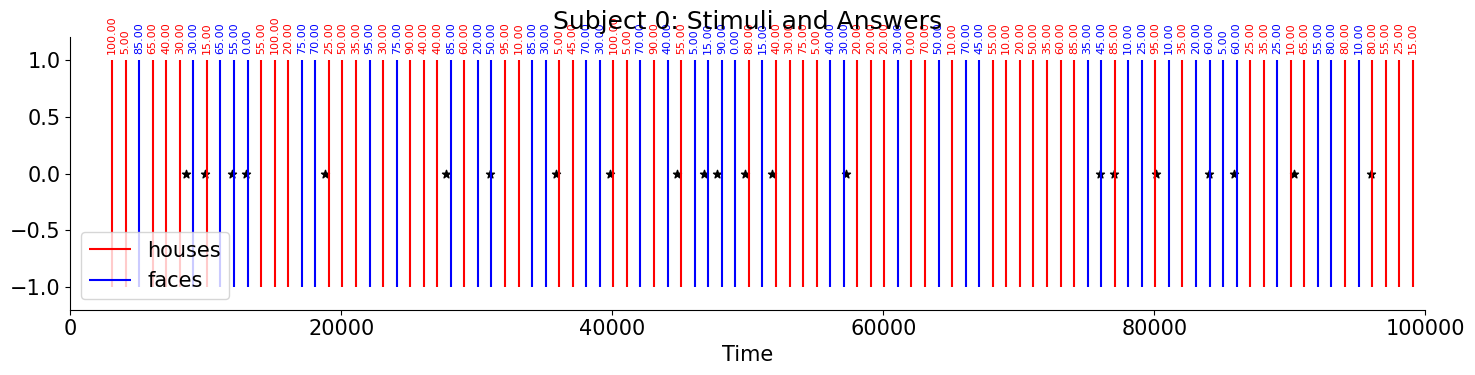

<Figure size 2000x400 with 0 Axes>

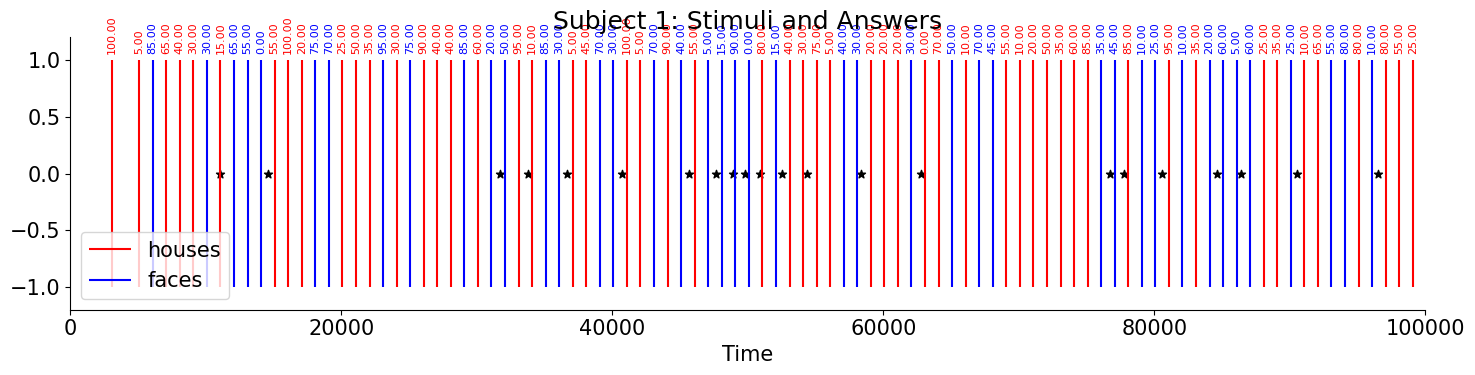

<Figure size 2000x400 with 0 Axes>

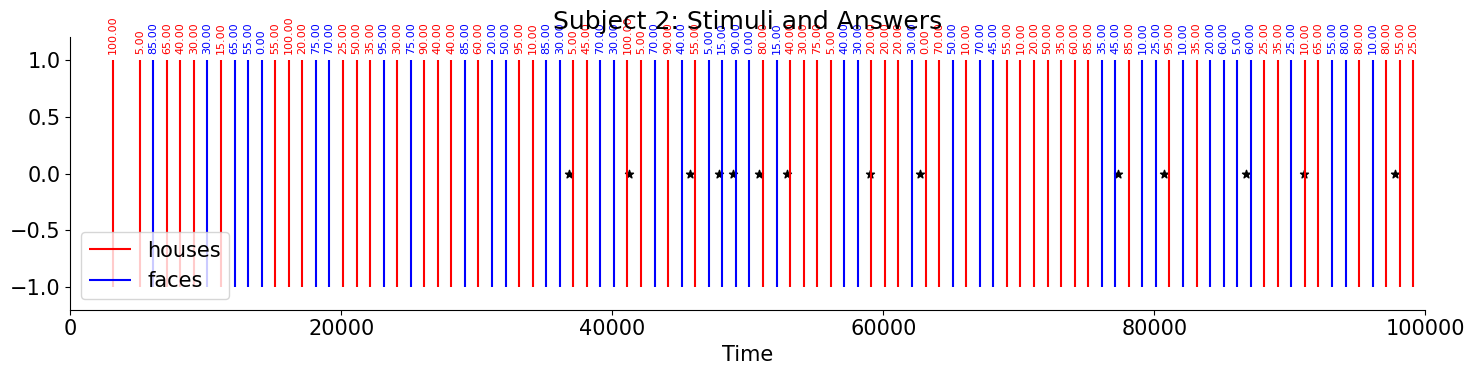

<Figure size 2000x400 with 0 Axes>

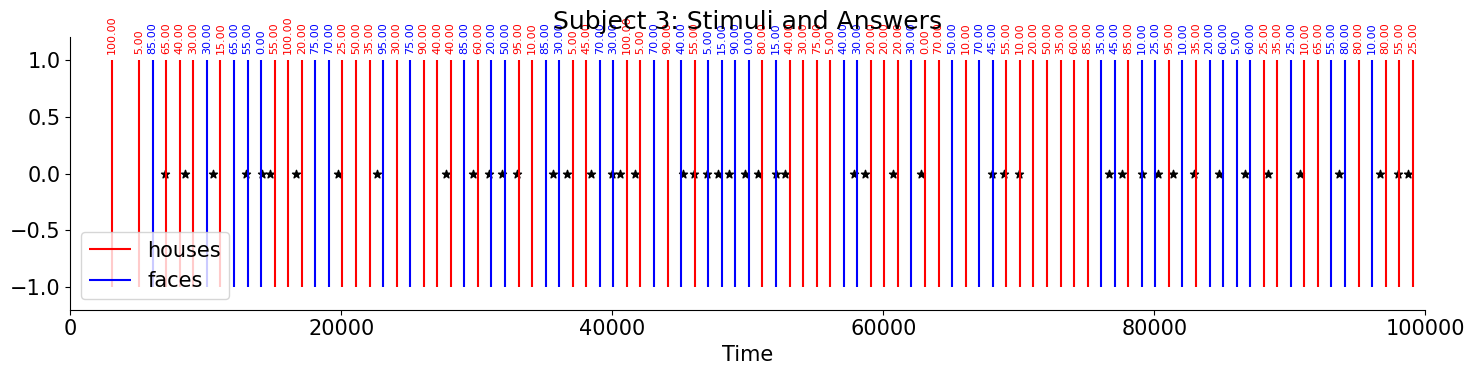

<Figure size 2000x400 with 0 Axes>

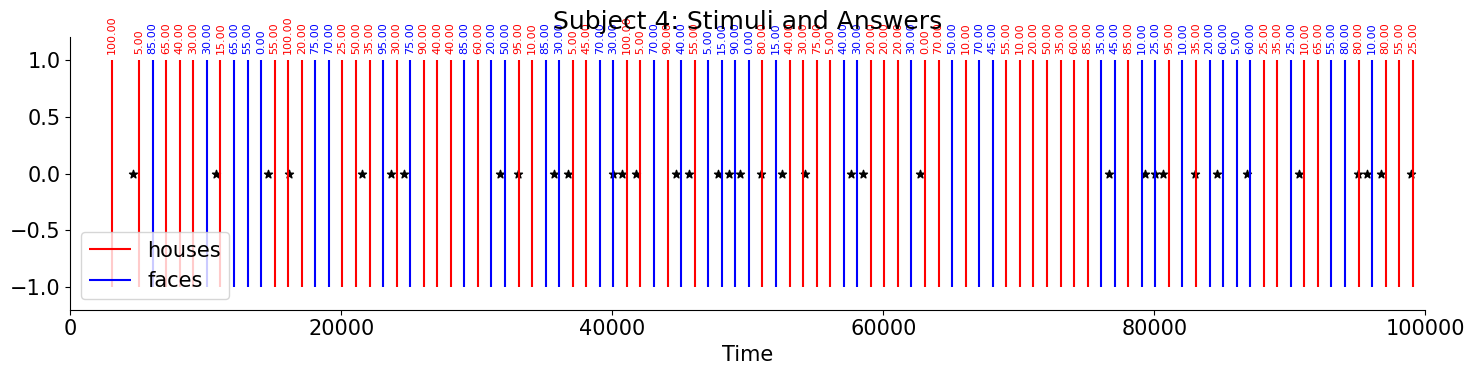

<Figure size 2000x400 with 0 Axes>

In [ ]:
subjects2_kept = [subjects2[j] for j in [0, 3, 4, 5, 6]]
lim1 = 0
lim2 = 100000

for i, subject in enumerate(subjects2_kept):
    house_on = subject['t_on'].flatten()[subject["stim_cat"].flatten() == 1]
    house_select = (house_on >= lim1) & (house_on <= lim2)
    house_on = house_on[house_select]
    house_off = subject['t_off'].flatten()[subject["stim_cat"].flatten() == 1][house_select]
    house_noise = subject['stim_noise'].flatten()[subject["stim_cat"].flatten() == 1][house_select]

    face_on = subject['t_on'].flatten()[subject["stim_cat"].flatten() == 2]
    face_select = (face_on >= lim1) & (face_on <= lim2)
    face_on = face_on[face_select]
    face_off = subject['t_off'].flatten()[subject["stim_cat"].flatten() == 2][face_select]
    face_noise = subject['stim_noise'].flatten()[subject["stim_cat"].flatten() == 2][face_select]

    answers = subject["key_press"].flatten()
    answers_select = (answers >= lim1) & (answers <= lim2)
    answers = answers[answers_select]

    fig = plt.figure(figsize=(15, 4))
    ax = fig.add_subplot()

    ax.vlines(house_on, -1, 1, colors="red", label='houses')
    ax.vlines(face_on, -1, 1, colors="blue", label="faces")

    # Annotate noise levels
    for t, n in zip(house_on, house_noise):
        ax.text(t, 1.05, f"{n:.2f}", color='red', fontsize=8, rotation=90, ha='center', va='bottom')

    for t, n in zip(face_on, face_noise):
        ax.text(t, 1.05, f"{n:.2f}", color='blue', fontsize=8, rotation=90, ha='center', va='bottom')

    ax.scatter(answers, np.zeros(answers.shape), marker="*", color="black")
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlim(lim1, lim2)
    ax.set_title(f"Subject {i}: Stimuli and Answers")
    ax.set_xlabel("Time")
    plt.tight_layout()
    plt.legend()
    plt.show()
    plt.clf()


/tmp/ipython-input-14-769802041.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', num_subjects)


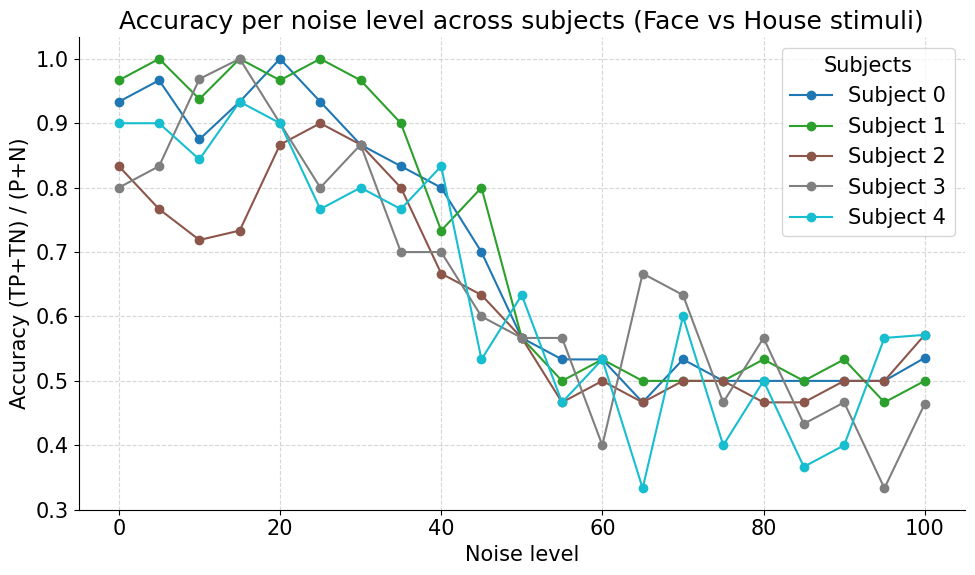

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Create a color map for different subjects
num_subjects = len(subjects2_kept)
colors = cm.get_cmap('tab10', num_subjects)

# Prepare the figure
plt.figure(figsize=(10, 6))

all_subjects_accuracies = []

for i, subject in enumerate(subjects2_kept):
    # Extract face stimuli
    face_on = subject['t_on'].flatten()[subject["stim_cat"].flatten() == 2]
    face_noise = subject['stim_noise'].flatten()[subject["stim_cat"].flatten() == 2]

    # Extract house stimuli
    house_on = subject['t_on'].flatten()[subject["stim_cat"].flatten() == 1]
    house_noise = subject['stim_noise'].flatten()[subject["stim_cat"].flatten() == 1]

    # Extract answer times
    answers = subject["key_press"].flatten()
    stimuli_answers = np.zeros(subject['t_on'].flatten().shape, dtype=bool)
    for k in range(len(subject['t_on'].flatten())):
        t_start = subject['t_on'].flatten()[k] + 200
        t_end = subject['t_on'].flatten()[k] + 1200
        if np.any((answers > t_start) & (answers <= t_end)):
            stimuli_answers[k] = True

    face_answers = stimuli_answers[subject["stim_cat"].flatten() == 2]
    house_answers = stimuli_answers[subject["stim_cat"].flatten() == 1]

    # Group by noise level
    unique_noise_levels = np.unique(subject['stim_noise'].flatten())
    accuracy_counts = []

    for noise in unique_noise_levels:
        mask_face = face_noise == noise
        mask_house = house_noise == noise
        TP = np.sum(face_answers[mask_face])
        FP = np.sum(house_answers[mask_house])
        TN = np.sum(~house_answers[mask_house])
        P = np.sum(mask_face)
        N = np.sum(mask_house)
        accuracy = (TP + TN) / (P + N)
        accuracy_counts.append(accuracy)

    # Plot on the same figure
    all_subjects_accuracies.append(accuracy_counts)
    plt.plot(unique_noise_levels, accuracy_counts, marker='o', color=colors(i), label=f"Subject {i}")

# Final plot formatting
plt.xlabel("Noise level")
plt.ylabel("Accuracy (TP+TN) / (P+N)")
plt.title("Accuracy per noise level across subjects (Face vs House stimuli)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Subjects")
plt.tight_layout()
plt.show()


/tmp/ipython-input-15-2730394370.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', num_subjects)


Subject 0
S0
T=42.9
S=0.2
C=0.50
L=0.06
R²=0.98
Subject 1
S1
T=43.1
S=0.2
C=0.50
L=0.02
R²=0.97
Subject 2
S2
T=43.1
S=0.3
C=0.50
L=0.19
R²=0.91
Subject 3
S3
T=39.3
S=0.1
C=0.49
L=0.09
R²=0.82
Subject 4
S4
T=42.6
S=0.2
C=0.47
L=0.12
R²=0.84


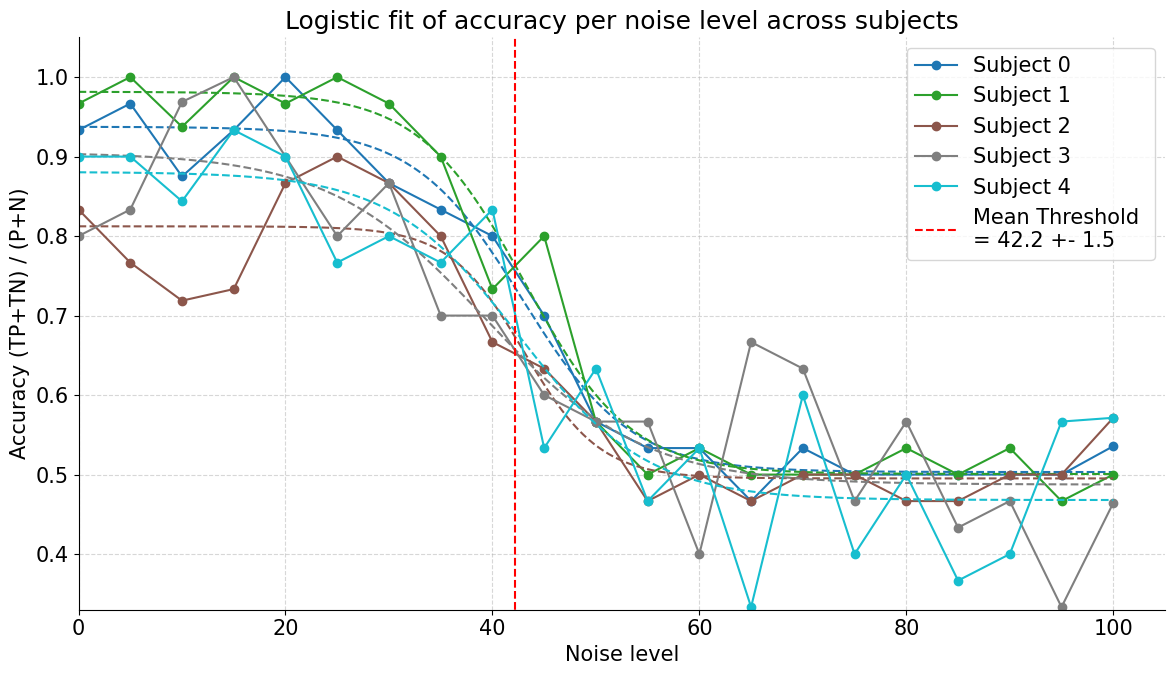

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import scipy.optimize as opt

def logistic(x, threshold, slope, chance_level, lapse_level):
    return (1 - lapse_level - chance_level) / (1. + np.exp(slope * (x - threshold))) + chance_level

# Create a color map for different subjects
num_subjects = len(subjects2_kept)
colors = cm.get_cmap('tab10', num_subjects)

# Prepare the figure
plt.figure(figsize=(12, 7))

all_subjects_parameters = []

for i, subject in enumerate(subjects2_kept):
    current_accuracy = all_subjects_accuracies[i]
    noise_levels = np.arange(0, 105, 5)  # 0 to 100 in steps of 5

    try:
        # Fit logistic curve
        p0 = [50, 0.5, 0.5, 0.1]
        popt, pcov = opt.curve_fit(logistic, noise_levels, current_accuracy, p0=p0, method="trf")
        all_subjects_parameters.append(popt)

        # Generate data points for plotting
        x = np.linspace(0, 100, 200)
        log_reg = logistic(x, *popt)

        # Compute R²
        residuals = current_accuracy - logistic(noise_levels, *popt)
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((current_accuracy - np.mean(current_accuracy))**2)
        r_squared = 1 - (ss_res / ss_tot)

        # Plot data and fit
        print(f"Subject {i}")
        print(f"S{i}\nT={popt[0]:.1f}\nS={popt[1]:.1f}\nC={popt[2]:.2f}\nL={popt[3]:.2f}\nR²={r_squared:.2f}")
        print("=========")
        plt.plot(noise_levels, current_accuracy, marker='o', color=colors(i), label=f"Subject {i}")
        plt.plot(x, log_reg, color=colors(i), linestyle='--')

        # Annotate fit parameters
        text_x = 102
        text_y = log_reg[-1]
    except Exception as e:
        print(f"Fit failed for Subject {i}: {e}")
        plt.plot(noise_levels, current_accuracy, marker='x', linestyle='-', color=colors(i), label=f"Subject {i} (fit failed)")

# Finalize plot
all_subjects_parameters = np.array(all_subjects_parameters)
mean_parameters = np.mean(all_subjects_parameters, axis=0)
std_parameters = np.std(all_subjects_parameters, axis=0)
plt.vlines(mean_parameters[0], 0, 1.5, linestyle='--', color='red', label=f'Mean Threshold \n= {mean_parameters[0]:.1f} +- {std_parameters[0]:.1f}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel("Noise level")
plt.ylabel("Accuracy (TP+TN) / (P+N)")
plt.title("Logistic fit of accuracy per noise level across subjects")
plt.xlim(0, 105)
plt.ylim(0.33, 1.05)
plt.tight_layout()
plt.show()


/tmp/ipython-input-16-1202553794.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', num_bins)


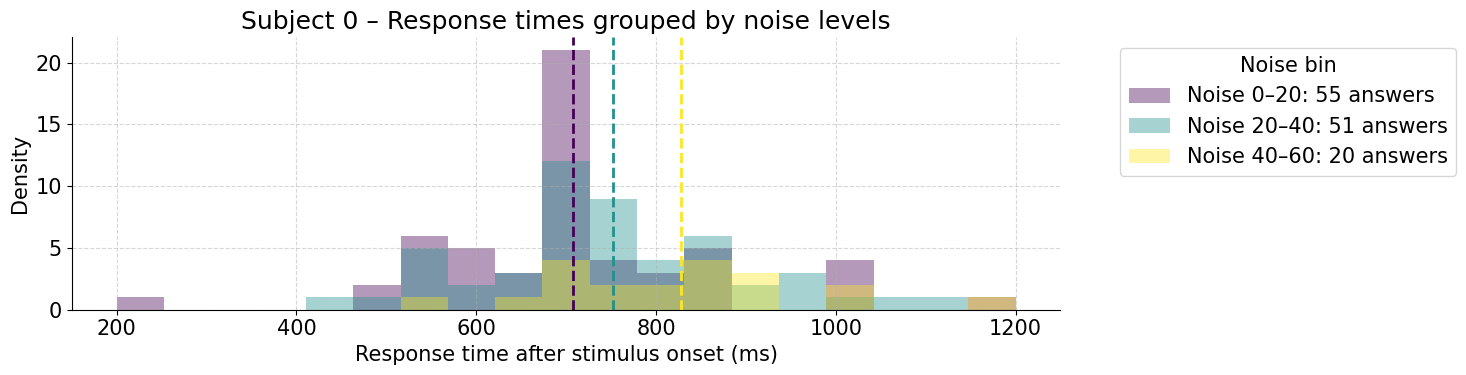

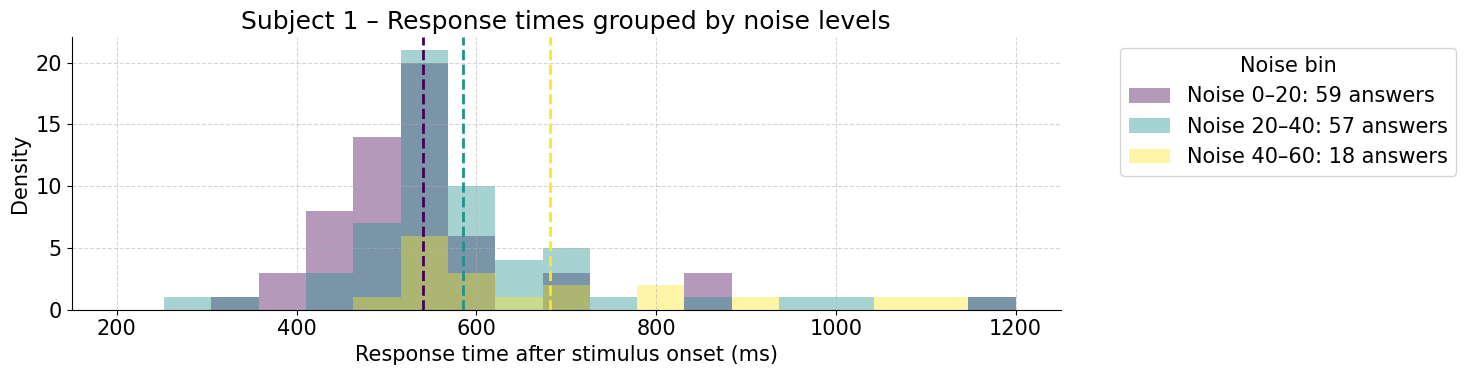

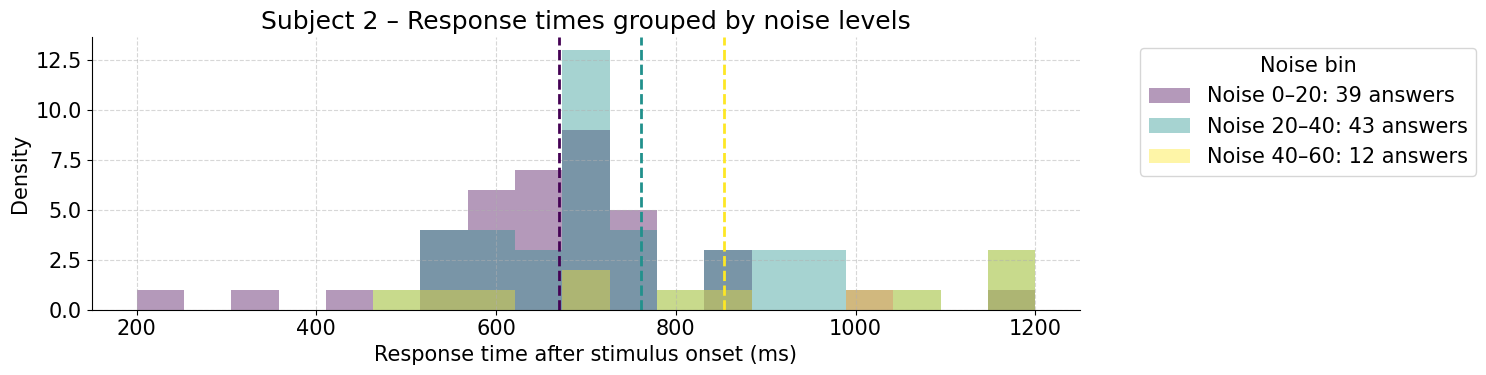

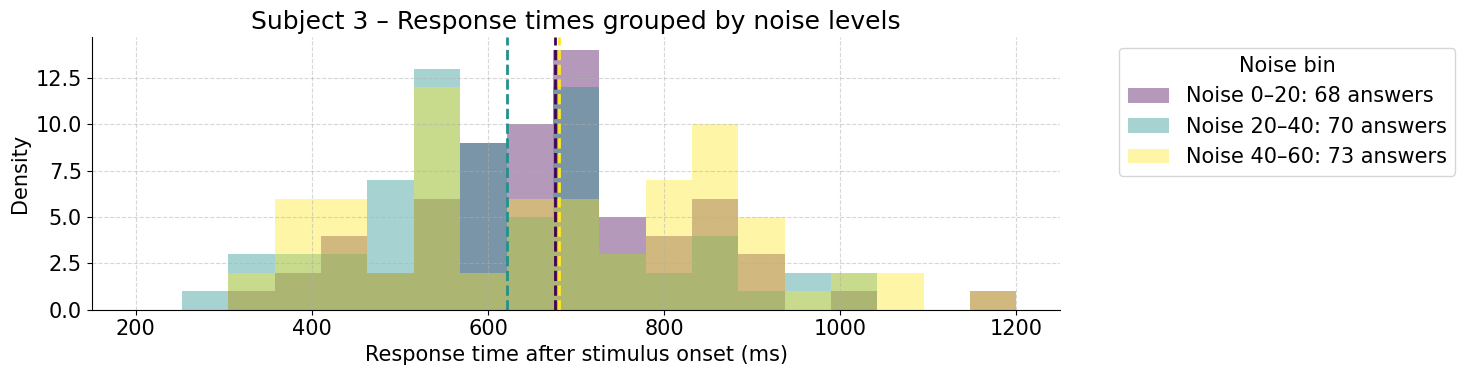

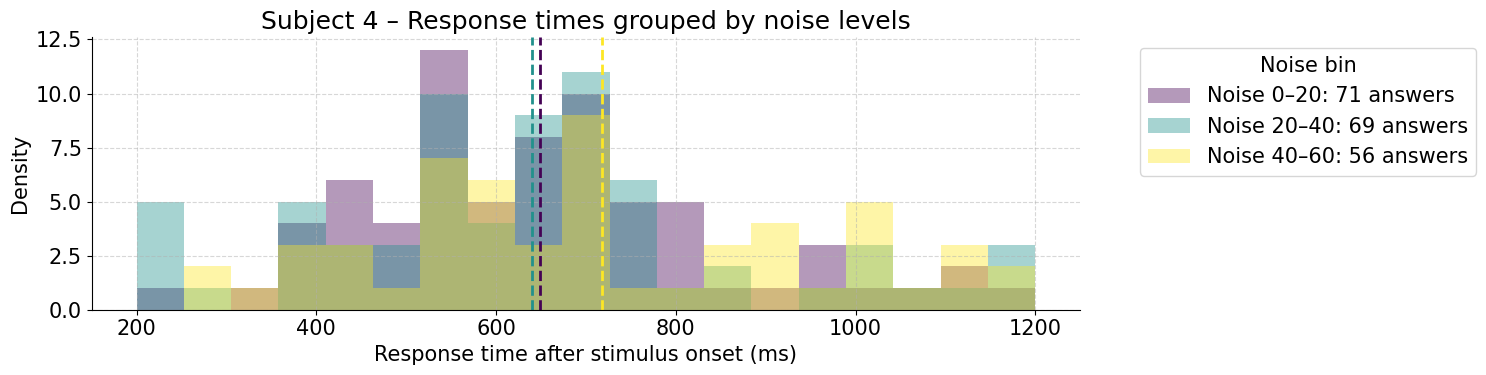

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Define noise bins
noise_bins = [0, 20, 40, 60]#, 80, 100]
noise_bin_labels = [f"{noise_bins[i]}–{noise_bins[i+1]}" for i in range(len(noise_bins)-1)]
num_bins = len(noise_bin_labels)

subjects2_kept = [subjects2[j] for j in [0, 3, 4, 5, 6]]

for i, subject in enumerate(subjects2_kept):
    answers = subject["key_press"].flatten()

    fig = plt.figure(figsize=(15, 4))
    ax = fig.add_subplot()

    t_on_all = subject['t_on'].flatten()
    stim_noise_all = subject['stim_noise'].flatten()

    stimuli_answers = -np.ones_like(t_on_all)

    # Compute response times relative to stimulus onset
    for k in range(len(t_on_all)):
        t_start = t_on_all[k] + 200
        t_end = t_on_all[k] + 1200
        valid_answers = answers[(answers > t_start) & (answers <= t_end)]
        if valid_answers.size > 0:
            this_answer = valid_answers[0]
            stimuli_answers[k] = this_answer - t_on_all[k]

    # Color map and histogram bins
    cmap = cm.get_cmap('viridis', num_bins)
    bins = np.linspace(200, 1200, 20)  # Response time bins (ms)

    for j in range(num_bins):
        lower = noise_bins[j]
        upper = noise_bins[j+1]
        mask_noise = (stim_noise_all >= lower) & (stim_noise_all < upper)
        mask_resp = stimuli_answers != -1
        selected = mask_noise & mask_resp

        rt = stimuli_answers[selected]
        count = np.sum(selected)

        # Plot histogram
        ax.hist(rt, bins=bins, alpha=0.4, color=cmap(j),
                label=f"Noise {noise_bin_labels[j]}: {count} answers", density=False)

        # Add vertical line for mean and shaded area for std
        if count > 1:
            mean_rt = np.mean(rt)
            std_rt = np.std(rt)
            ax.axvline(mean_rt, color=cmap(j), linestyle='--', linewidth=2)

    ax.set_title(f"Subject {i} – Response times grouped by noise levels")
    ax.set_xlabel("Response time after stimulus onset (ms)")
    ax.set_ylabel("Density")
    ax.legend(title="Noise bin", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

def plot_response_vs_noise(data, subject_id, noise_min=0, noise_max=60, show_regression=True):
    """
    Plot noise level vs response time with scatter, violin plots (per unique noise), and regression.

    Parameters:
        data (dict): Dataset containing subject responses.
        subject_id (int): Index of the subject.
        noise_min (float): Minimum noise level to include.
        noise_max (float): Maximum noise level to include.
        show_regression (bool): Whether to include linear regression line.
    """
    subject = data[subject_id]
    answers = subject["key_press"].flatten()
    t_on_all = subject['t_on'].flatten()
    stim_noise_all = subject['stim_noise'].flatten()
    stimuli_answers = -np.ones_like(t_on_all)

    # Compute response times
    for k in range(len(t_on_all)):
        t_start = t_on_all[k] + 200
        t_end = t_on_all[k] + 1200
        valid_answers = answers[(answers > t_start) & (answers <= t_end)]
        if valid_answers.size > 0:
            this_answer = valid_answers[0]
            stimuli_answers[k] = this_answer - t_on_all[k]

    # Apply masks
    mask_resp = stimuli_answers != -1
    mask_noise = (stim_noise_all >= noise_min) & (stim_noise_all < noise_max)
    mask = mask_resp & mask_noise

    noise_vals = stim_noise_all[mask]
    rt_vals = stimuli_answers[mask]

    # Spearman correlation
    rho, pval = spearmanr(noise_vals, rt_vals)

    # Plot setup
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    # Scatter plot
    ax.scatter(noise_vals, rt_vals, alpha=0.4, color='tab:blue', label='Trials', zorder=2)

    # Linear regression (optional)
    if show_regression and len(noise_vals) > 1:
        coef = np.polyfit(noise_vals, rt_vals, 1)
        poly = np.poly1d(coef)
        x_fit = np.linspace(noise_vals.min(), noise_vals.max(), 100)
        y_fit = poly(x_fit)
        ax.plot(x_fit, y_fit, color='red', linestyle='--', label='Linear fit', zorder=3)

    # Violin plots per unique noise level
    unique_noises = np.unique(noise_vals)
    rt_by_noise = [rt_vals[noise_vals == n] for n in unique_noises]

    parts = ax.violinplot(rt_by_noise, positions=unique_noises,
                          showmeans=False, showextrema=False,
                          widths=0.8)

    for idx, (pc, rts, noise) in enumerate(zip(parts['bodies'], rt_by_noise, unique_noises)):
        pc.set_alpha(0.3)
        pc.set_facecolor('gray')
        pc.set_edgecolor('black')
        pc.set_linewidth(0.5)

        # Draw mean and median lines
        mean_val = np.mean(rts)
        median_val = np.median(rts)
        width = 1.0

        ax.hlines(mean_val, noise - width, noise + width, colors='black', linestyles='solid', linewidth=1.5)
        ax.hlines(median_val, noise - width, noise + width, colors='black', linestyles='dotted', linewidth=1.5)

    # Labels, title, stats
    ax.set_xlabel("Noise level")
    ax.set_ylabel("Response time (ms)")
    ax.set_title(f"Subject {subject_id} — Noise vs Response Time")
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend()

    # Annotate correlation
    ax.text(0.05, 0.95, f"Spearman ρ = {rho:.2f}\np = {pval:.4f}",
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.tight_layout()
    plt.show()

    # Console output
    print(f"Subject {subject_id} — Spearman ρ = {rho:.3f}, p = {pval:.4f}")


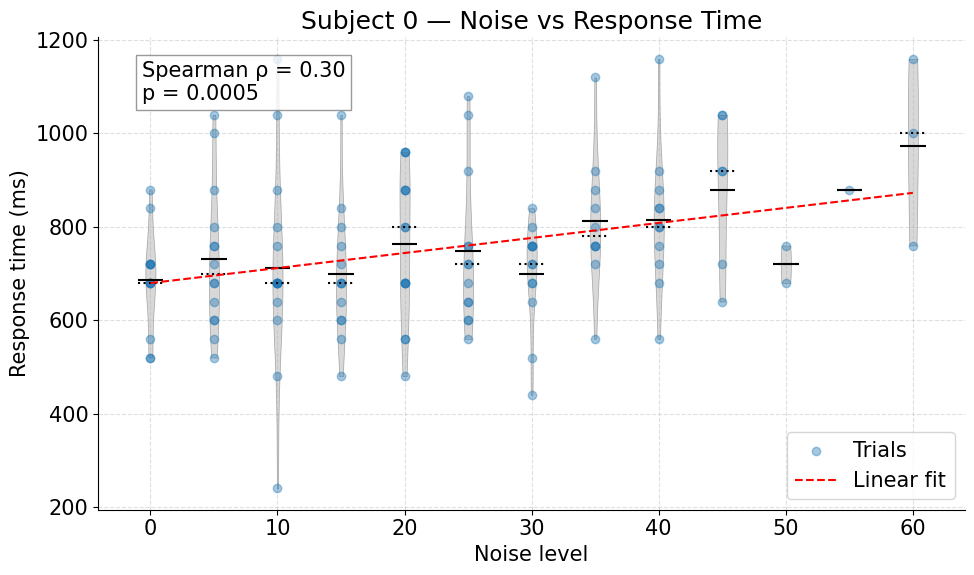

Subject 0 — Spearman ρ = 0.302, p = 0.0005


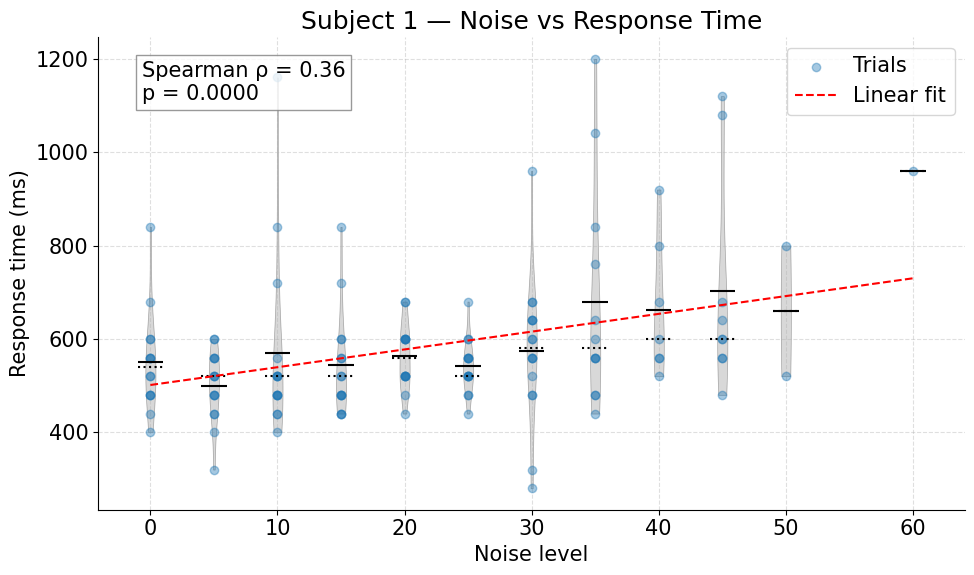

Subject 1 — Spearman ρ = 0.356, p = 0.0000


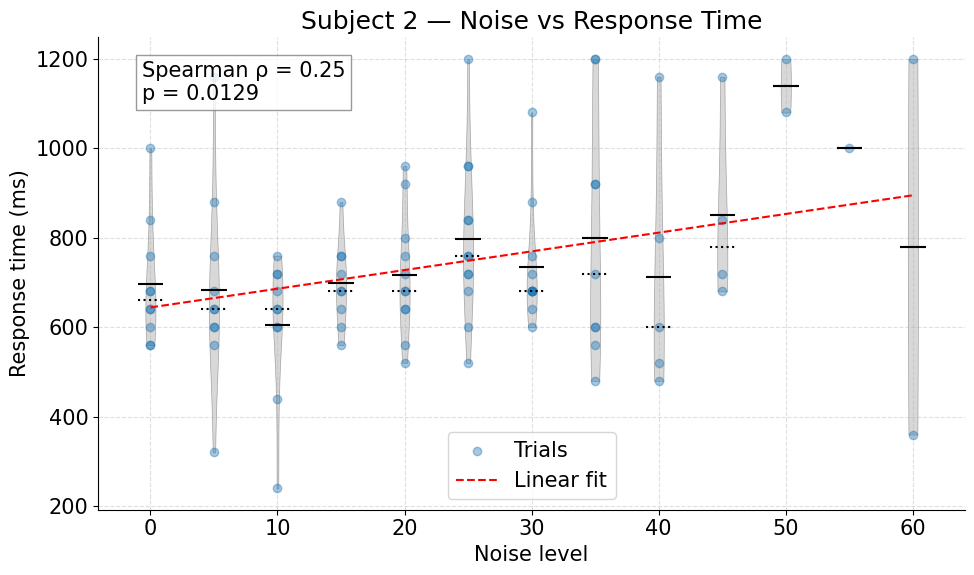

Subject 2 — Spearman ρ = 0.253, p = 0.0129


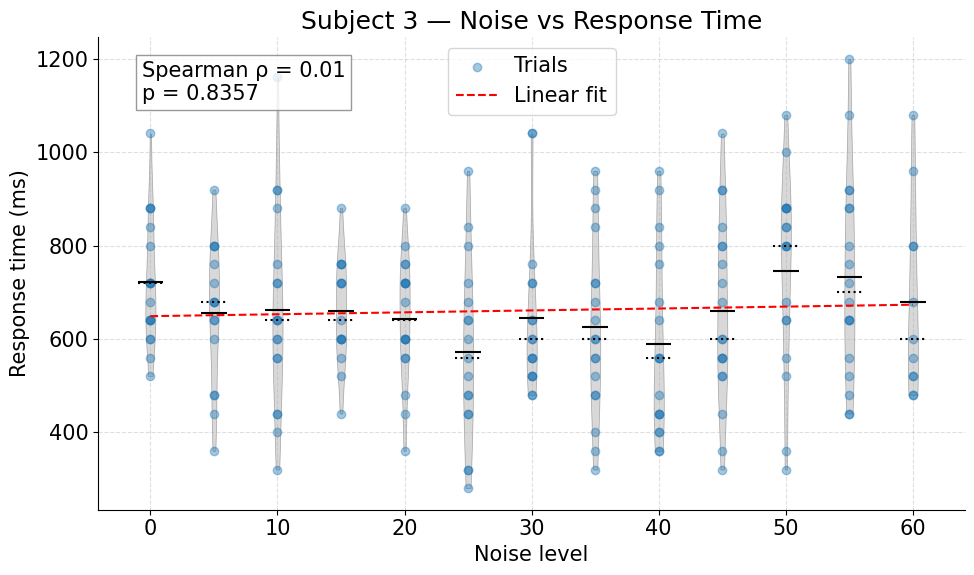

Subject 3 — Spearman ρ = 0.014, p = 0.8357


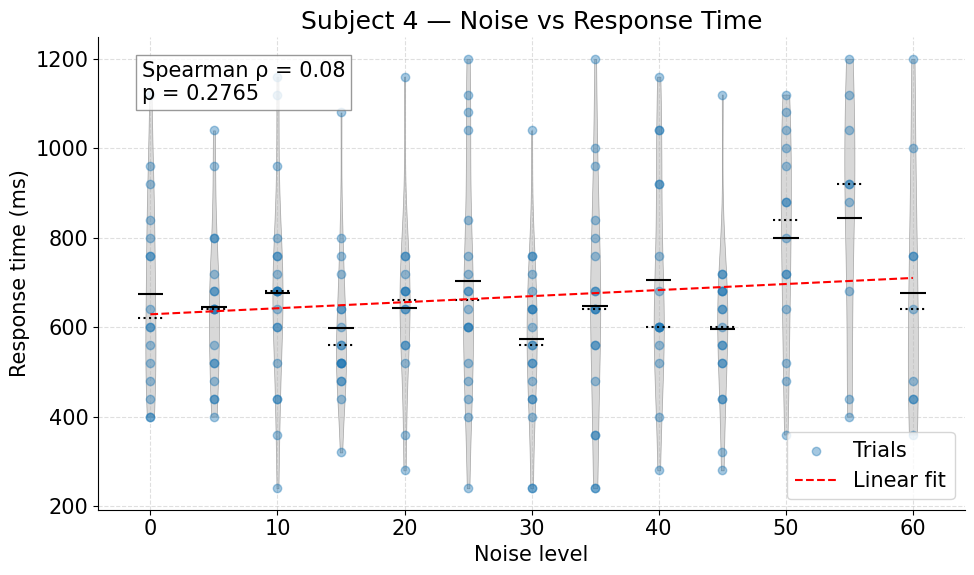

Subject 4 — Spearman ρ = 0.076, p = 0.2765


In [ ]:

for subj in range(5):
  plot_response_vs_noise(subjects2_kept, subj, noise_max=65)

In [ ]:

subjects2_kept = [subjects2[j] for j in [0, 3, 4]]
noise_bins = [0, 20, 40]
noise_bin_labels = [f"{noise_bins[i]}–{noise_bins[i+1]}" for i in range(len(noise_bins)-1)]
num_bins = len(noise_bin_labels)

response_times = []

for i, subject in enumerate(subjects2_kept):
    answers = subject["key_press"].flatten()

    t_on_all = subject['t_on'].flatten()
    stim_noise_all = subject['stim_noise'].flatten()

    stimuli_answers = -np.ones_like(t_on_all, dtype=float)

    # Compute response times relative to stimulus onset
    for k in range(len(t_on_all)):
        t_start = t_on_all[k] + 200
        t_end = t_on_all[k] + 1200
        valid_answers = answers[(answers > t_start) & (answers <= t_end)]
        if valid_answers.size > 0:
            this_answer = valid_answers[0]
            stimuli_answers[k] = this_answer - t_on_all[k]

    participant_rts = []

    for j in range(num_bins):
        lower = noise_bins[j]
        upper = noise_bins[j+1]
        mask_noise = (stim_noise_all >= lower) & (stim_noise_all < upper)
        mask_resp = stimuli_answers != -1
        selected = mask_noise & mask_resp

        participant_rts.append(stimuli_answers[selected])

    response_times.append(participant_rts)

Subject 0, Noise 0–20 : Mean = 707.64; std = 157.23
Subject 1, Noise 0–20 : Mean = 541.02; std = 130.57
Subject 2, Noise 0–20 : Mean = 669.74; std = 156.82


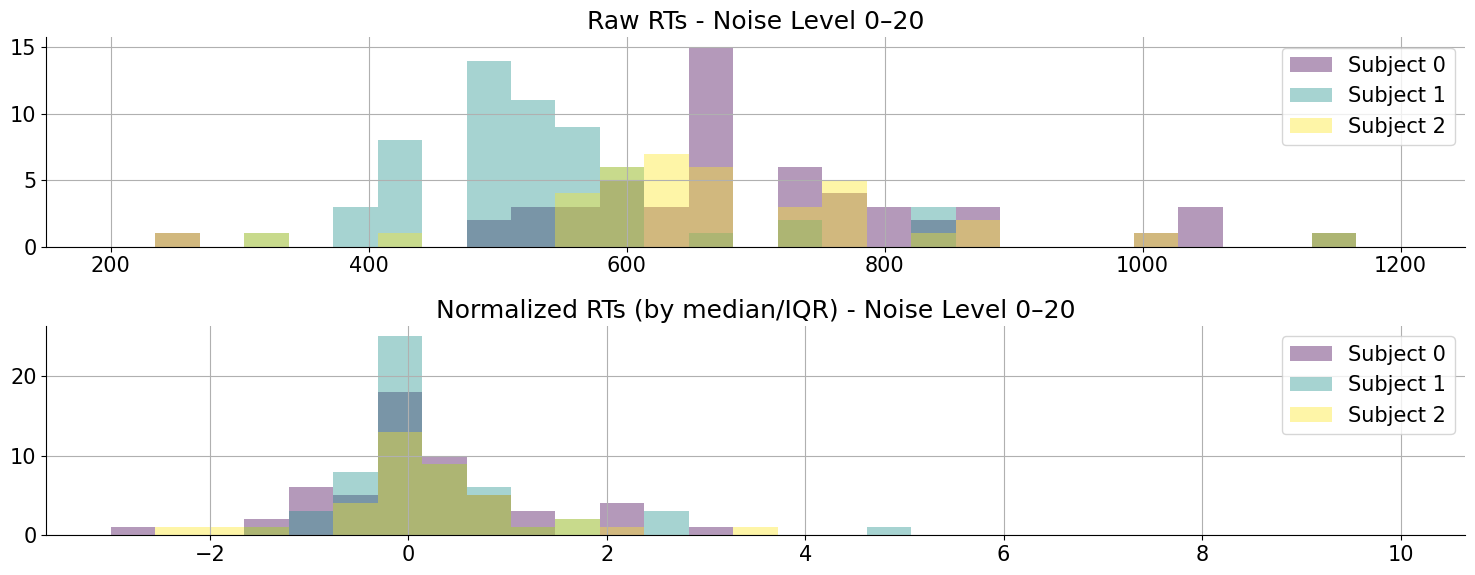

Subject 0, Noise 20–40 : Mean = 752.16; std = 146.92
Subject 1, Noise 20–40 : Mean = 585.26; std = 147.33
Subject 2, Noise 20–40 : Mean = 760.93; std = 179.61


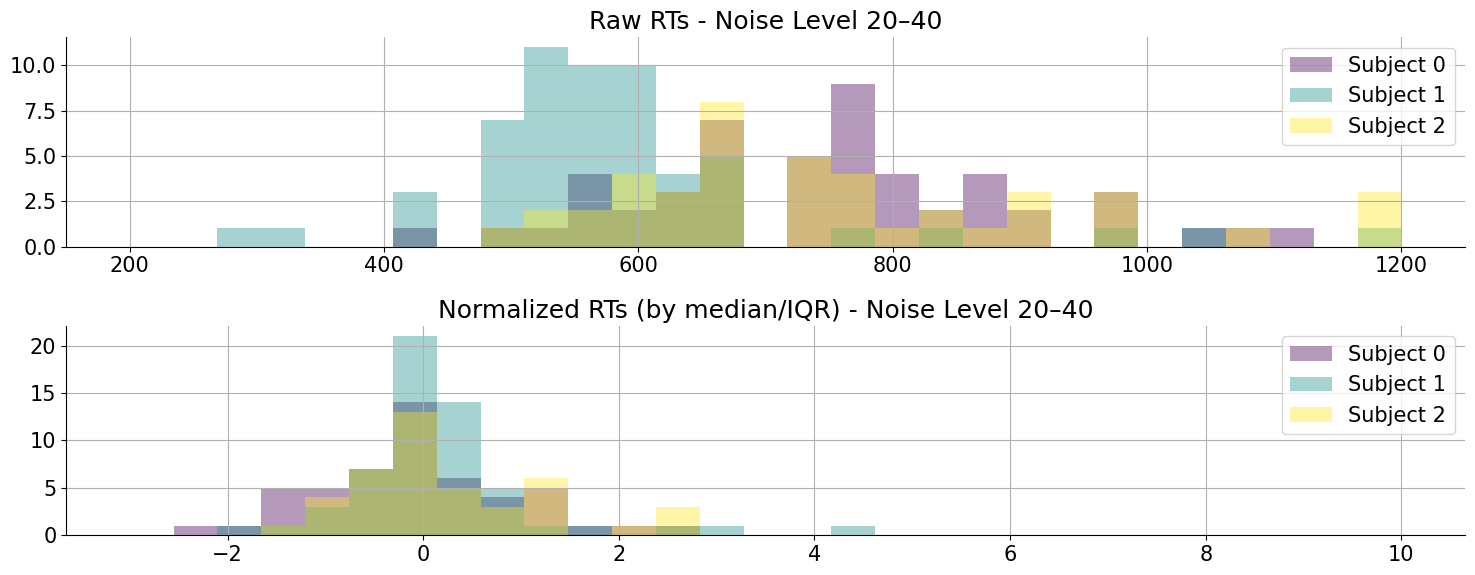

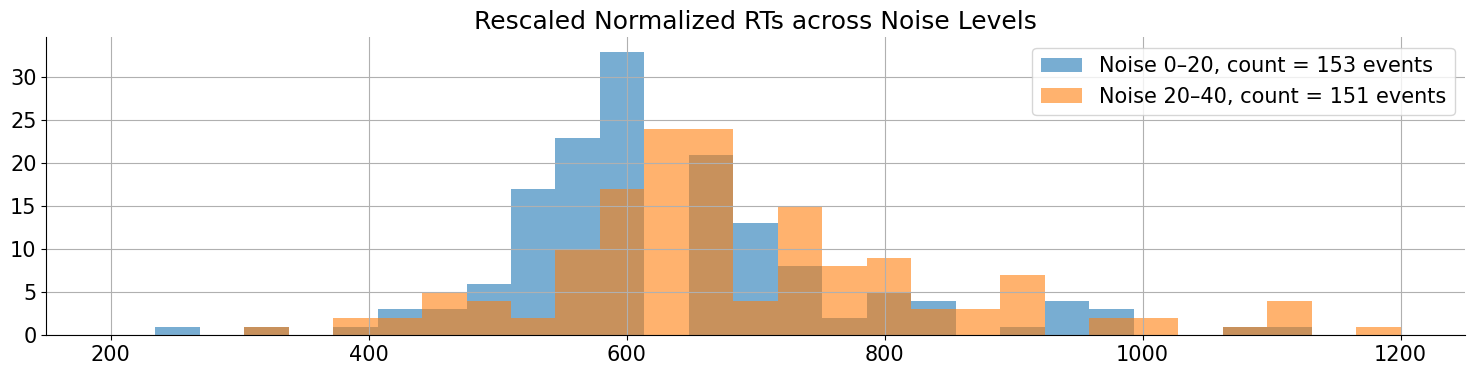

In [ ]:
from scipy.stats import iqr
import matplotlib.pyplot as plt
import numpy as np

grouped_rts = []
for noise_idx in range(num_bins):
    fig = plt.figure(figsize=(15, 6))
    ax1 = fig.add_subplot(2, 1, 1)  # Top: raw RT histogram
    ax2 = fig.add_subplot(2, 1, 2)  # Bottom: normalized RT histogram

    grouped = []
    mean_grouped = []
    std_grouped = []
    IQR_grouped = []
    median_grouped = []
    hist_bins_1 = np.linspace(200, 1200, 30)
    hist_bins_2 = np.linspace(-3, 10, 30)

    for subj_idx, subject in enumerate(subjects2_kept):
        rt_data = response_times[subj_idx][noise_idx]
        color = cmap(subj_idx)

        # Raw RT histogram
        ax1.hist(rt_data, alpha=0.4, color=color, bins=hist_bins_1,
                 label=f"Subject {subj_idx}", density=False)

        # Compute stats
        mean_rt = np.mean(rt_data)
        std_rt = np.std(rt_data)
        median_rt = np.median(rt_data)
        iqr_rt = iqr(rt_data)

        print(f"Subject {subj_idx}, Noise {noise_bin_labels[noise_idx]} : "
              f"Mean = {mean_rt:.2f}; std = {std_rt:.2f}")

        mean_grouped.append(mean_rt)
        std_grouped.append(std_rt)
        IQR_grouped.append(iqr_rt)
        median_grouped.append(median_rt)

        # Normalize
        if iqr_rt == 0:
            new_distrib = np.zeros_like(rt_data)
        else:
            new_distrib = (rt_data - median_rt) / std_rt
        grouped.extend(new_distrib.tolist())

        # Plot normalized RT histogram
        ax2.hist(new_distrib, bins=hist_bins_2, alpha=0.4, color=color,
                 label=f"Subject {subj_idx}", density=False)

    # Rescale normalized grouped RTs back to a common scale
    grouped = np.array(grouped) * np.mean(std_grouped) + np.mean(median_grouped)
    grouped_rts.append(grouped)

    ax1.set_title(f"Raw RTs - Noise Level {noise_bin_labels[noise_idx]}")
    ax1.legend()
    ax1.grid(True)

    ax2.set_title(f"Normalized RTs (by median/IQR) - Noise Level {noise_bin_labels[noise_idx]}")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Summary histogram of all normalized (rescaled) grouped RTs
fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot()
for noise_idx in range(num_bins):
    ax.hist(grouped_rts[noise_idx], density=False,
            label=f"Noise {noise_bin_labels[noise_idx]}, count = {len(grouped_rts[noise_idx])} events",
            alpha=0.6, bins=hist_bins_1)
ax.set_title("Rescaled Normalized RTs across Noise Levels")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# First-passage time density for a 1-boundary DDM (Ratcliff)
def ddm_pdf(rt, v, a, t0, s=1.0):
    rt = np.asarray(rt)
    rt = np.maximum(rt - t0, 1e-4)  # avoid zero or negative time
    z = a / s
    mu = v / s
    return (z / np.sqrt(2 * np.pi * rt**3)) * np.exp(-(z - mu * rt)**2 / (2 * rt))


# Negative log-likelihood function
def ddm_neg_loglik(params, rt):
    v, a, t0 = params
    if a <= 0 or t0 <= 0:
        return np.inf
    pdf_vals = ddm_pdf(rt, v, a, t0)
    # Avoid log(0)
    pdf_vals = np.maximum(pdf_vals, 1e-10)
    return -np.sum(np.log(pdf_vals))

# Fit the DDM to RT data (only 'go' trials)
def fit_go_ddm(rt_go):
    # Initial guesses: [v, a, t0]
    x0 = [1.0, 1.0, 0.3]
    bounds = [(0.1, 10), (0.01, 10), (0.01, 1.0)]

    res = minimize(ddm_neg_loglik, x0, args=(rt_go,), bounds=bounds, method='L-BFGS-B')
    return res.x  # [v, a, t0]


In [ ]:
def simulate_ddm_trajectories(v, a, t0, n_traj=150, s=1.0, dt=0.001, max_t=5.0):
    """
    Simulates full DDM trajectories until the upper boundary is crossed.
    Returns list of (time, trajectory) arrays.
    """
    trajectories = []
    rts = []
    for _ in range(n_traj):
        x = 0.0
        t = 0.0
        traj = [x]
        times = [t]
        while x < a and t < max_t:
            dx = v * dt + s * np.sqrt(dt) * np.random.randn()
            x += dx
            t += dt
            traj.append(x)
            times.append(t)
        if t < max_t:
            rts.append(t0 + t)
            # shift the time to start at t0
            times = [ti + t0 for ti in times]
            trajectories.append((np.array(times), np.array(traj)))
    return rts, trajectories

5.1043152473944335 3.210932518186141 0.01


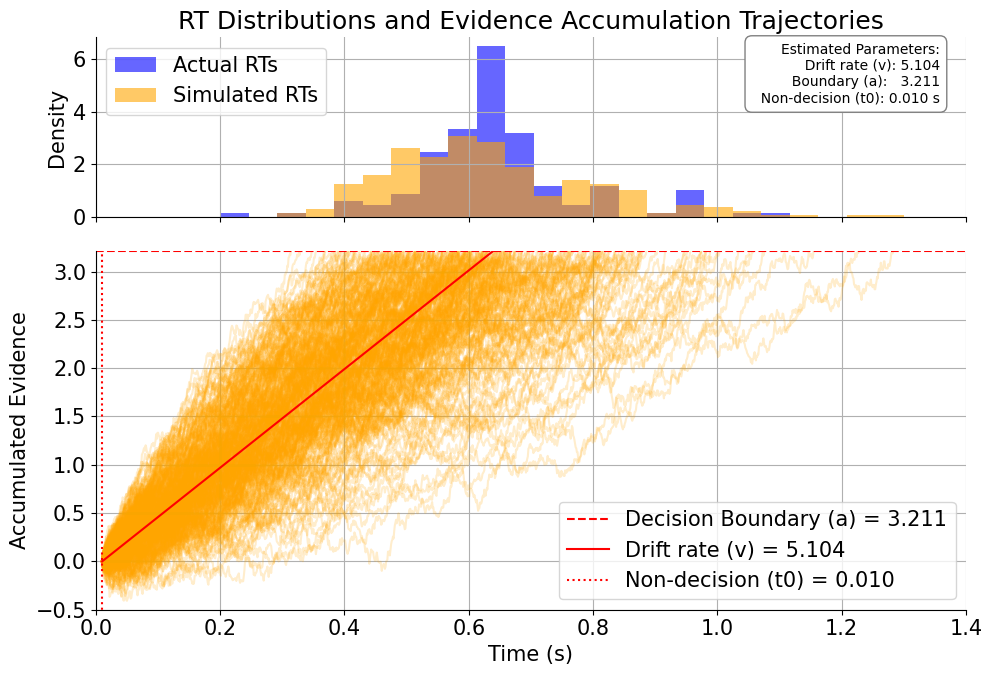

5.29234685944637 3.639157557740414 0.01


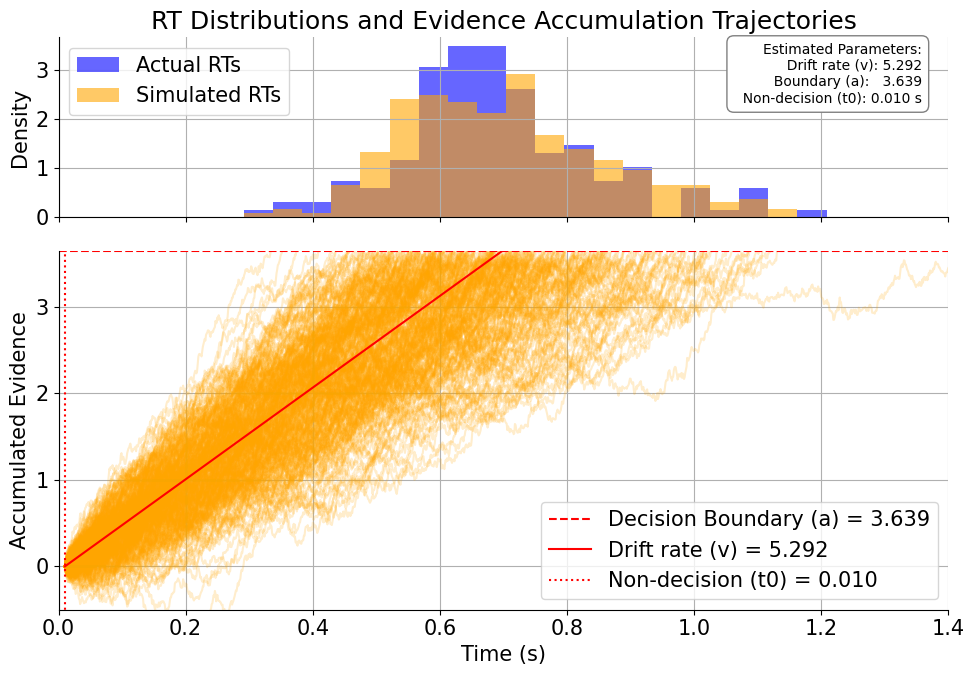

In [ ]:
results = []
hist_bins = np.linspace(200/1000, 1300/1000, 25)
for noise_idx in range(num_bins):
  rt_go = grouped_rts[noise_idx]/1000
  v, a, t0 = fit_go_ddm(rt_go)
  results.append({'bin': noise_idx, 'v': v, 'a': a, 't0': t0})
  print(v, a, t0 )

  # ==== Your estimated parameters (example values) ====
  v_est  = v     # drift rate (units: a/s)
  a_est  = a     # boundary height
  t0_est = t0     # non-decision time (seconds)

  # ==== Your actual RT data in seconds ====
  # Example: actual_rts = np.array([0.42, 0.35, 0.38, ...])
  # Replace the line below with your real RT vector
  actual_rts = grouped_rts[noise_idx]/1000  # or any way you load it

  # ==== Simulate RTs ====
  simulated_rts, trajectories = simulate_ddm_trajectories(v_est, a_est, t0_est, n_traj=300)

  # ==== Plot: Trajectories + RT histograms ====
  fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={"height_ratios": [1, 2]})

  # --- Top subplot: RT distribution ---
  axs[0].hist(actual_rts, alpha=0.6, label="Actual RTs", density=True, color='blue', bins=hist_bins)
  axs[0].hist(simulated_rts, alpha=0.6, label="Simulated RTs", density=True, color='orange', bins=hist_bins)
  axs[0].legend()
  axs[0].set_ylabel("Density")
  axs[0].set_title("RT Distributions and Evidence Accumulation Trajectories")
  axs[0].grid(True)

  # Parameter box in upper-right corner of top plot
  param_text = f"""Estimated Parameters:
  Drift rate (v): {v_est:.3f}
  Boundary (a):   {a_est:.3f}
  Non-decision (t0): {t0_est:.3f} s"""
  axs[0].text(
      0.97, 0.97, param_text,
      transform=axs[0].transAxes,
      fontsize=10,
      verticalalignment='top',
      horizontalalignment='right',
      bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray')
  )

  # --- Bottom subplot: Trajectories ---
  for times, traj in trajectories:
      axs[1].plot(times, traj, color='orange', alpha=0.2)

  axs[1].axhline(y=a_est, color='red', linestyle='--', label=f"Decision Boundary (a) = {a_est:.3f}")
  axs[1].plot([t0_est, t0_est + a_est/v_est], [0, a_est], color="red", label=f"Drift rate (v) = {v_est:.3f}")
  axs[1].axvline(x=t0_est, ymin=-.5, ymax=a_est, color="red", linestyle="dotted", label=f"Non-decision (t0) = {t0_est:.3f}")
  axs[1].set_xlabel("Time (s)")
  axs[0].set_xlim((0, 1.4))
  axs[1].set_ylim((-.5, a_est))
  axs[1].set_ylabel("Accumulated Evidence")
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

In [ ]:
from scipy.optimize import curve_fit

# Your piecewise linear peak function
def peak_function(x, base, ramp, peak, peak_amp, ramp2, steady):
    res = np.zeros_like(x, dtype=float)
    res[x <= ramp] = base
    res[x >= ramp2] = steady
    mask1 = (x > ramp) & (x <= peak)
    res[mask1] = base + (x[mask1] - ramp)/(peak - ramp) * (peak_amp - base)
    mask2 = (x > peak) & (x < ramp2)
    res[mask2] = peak_amp + (x[mask2] - peak)/(ramp2 - peak) * (steady - peak_amp)
    return res

# Helper function to fit the curve
from scipy.optimize import minimize

def fit_peak_function(x, y):
    def error_function(params):
        base, ramp, peak, peak_amp, ramp2, steady = params
        y_fit = peak_function(x, base, ramp, peak, peak_amp, ramp2, steady)
        return np.sum((y - y_fit) ** 2)

    # Initial guesses
    base_guess = np.median(y[x < 0])
    peak_idx = np.argmax(y[(x > 50) & (x < 400)])
    peak_time_guess = x[(x > 50) & (x < 400)][peak_idx]
    peak_amp_guess = y[(x > 50) & (x < 400)][peak_idx]
    ramp_guess = 50
    ramp2_guess = min(peak_time_guess + 200, x[-1])
    steady_guess = np.mean(y[x > 400])

    x0 = [base_guess, ramp_guess, peak_time_guess, peak_amp_guess, ramp2_guess, steady_guess]

    bounds = [
        (-np.inf, np.inf),  # base
        (0, 150),           # ramp
        (50, 500),          # peak
        (-np.inf, np.inf),  # peak_amp
        (100, x[-1]),       # ramp2
        (-np.inf, np.inf)   # steady
    ]

    # Constraints: peak_amp ≥ base, peak_amp ≥ steady
    constraints = [
        {'type': 'ineq', 'fun': lambda p: p[3] - p[0]},  # peak_amp - base ≥ 0
        {'type': 'ineq', 'fun': lambda p: p[3] - p[5]}   # peak_amp - steady ≥ 0
    ]

    result = minimize(error_function, x0, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        return result.x
    else:
        return None


/tmp/ipython-input-25-2156041756.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = get_cmap("tab10").colors  # color palette for different bins


Electrodes active in face : [ 0 33 34]
          
Electodes active in house : [33 34 40]
          
Electodes exclusive to face : [0]
          
Brodmann Areas : ['Brodmann area 18' 'Brodmann area 18']



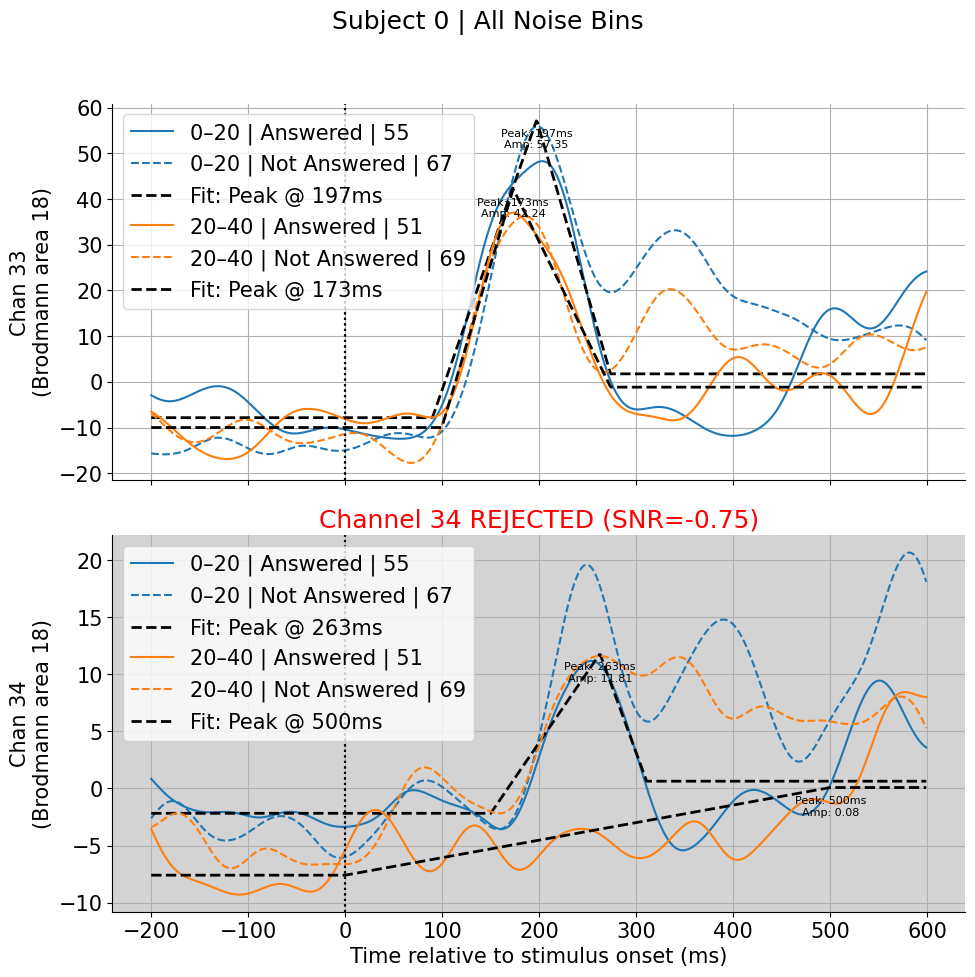

Electrodes active in face : [17 20 23 24 46]
          
Electodes active in house : [20 21]
          
Electodes exclusive to face : [17 23 24 46]
          
Brodmann Areas : ['Brodmann area 19' 'Brodmann area 37' 'Brodmann area 37']



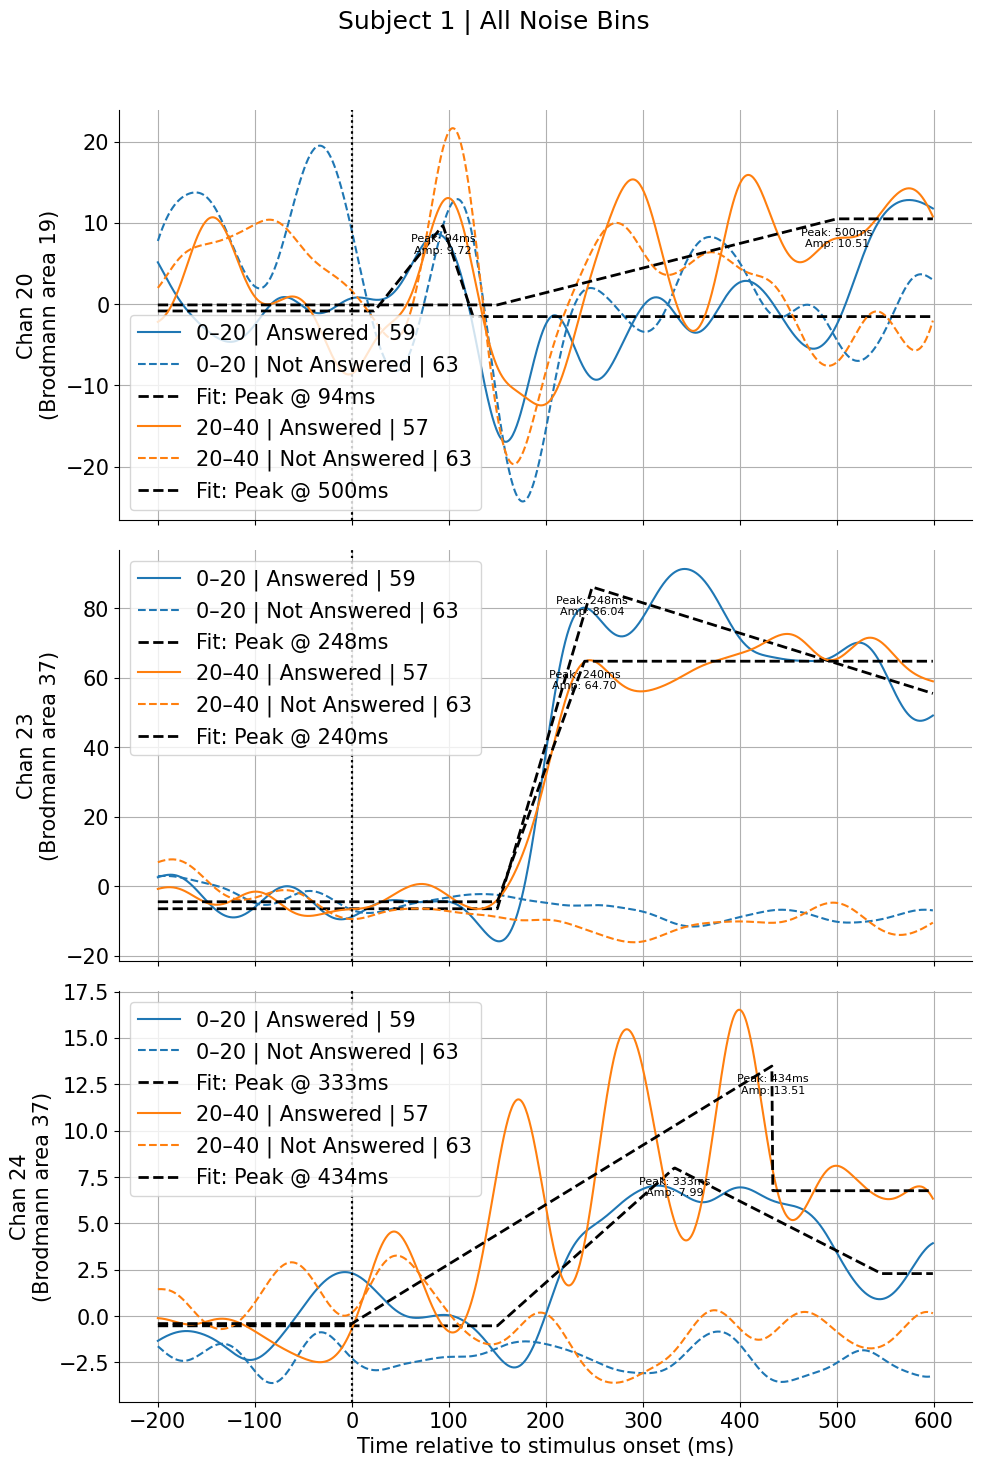

Electrodes active in face : [14 15]
          
Electodes active in house : [14]
          
Electodes exclusive to face : [15]
          
Brodmann Areas : ['Brodmann area 19' 'Brodmann area 19']



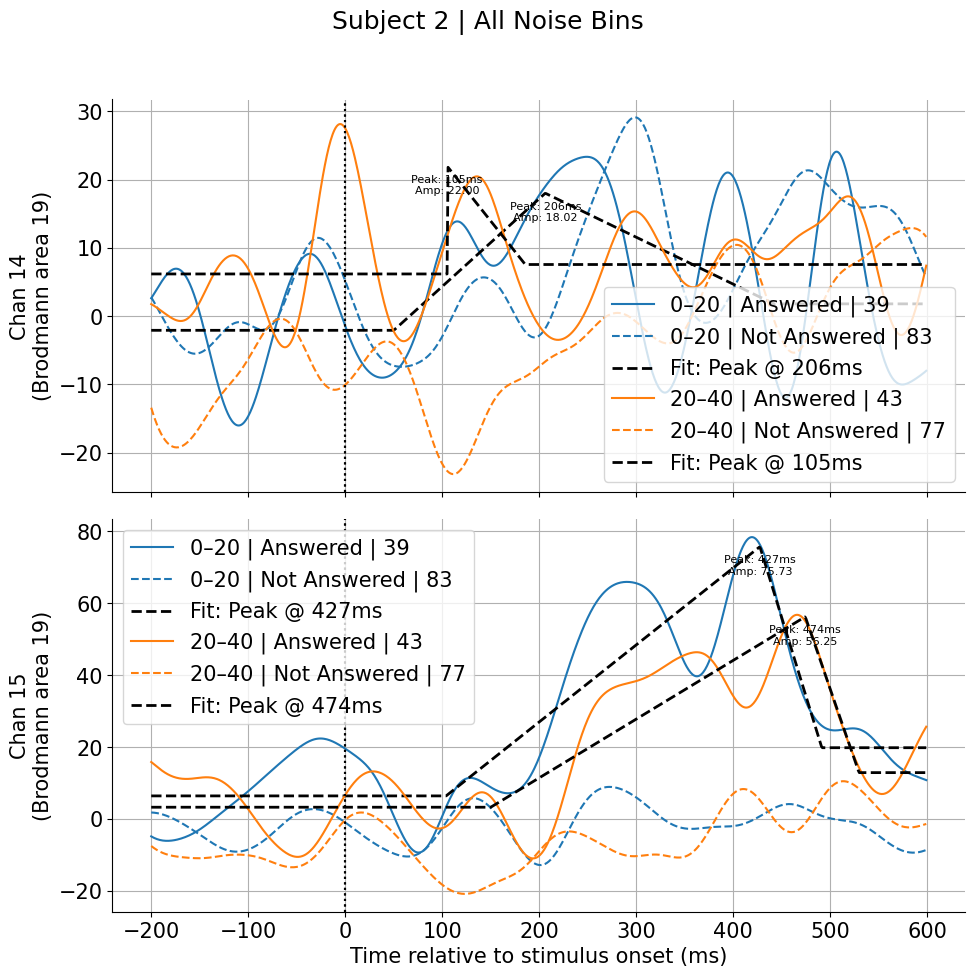

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from scipy.signal import savgol_filter

noise_bins = [0, 20, 40]
noise_bin_labels = [f"{noise_bins[i]}–{noise_bins[i+1]}" for i in range(len(noise_bins)-1)]
num_bins = len(noise_bin_labels)
colors = get_cmap("tab10").colors  # color palette for different bins

for subj_idx, subject in enumerate(subjects2_kept):

    # Selecting and displaying electrodes activated only when presented a face and not a house
    electrodes_indices = np.arange(len(all_active_electrodes_face[subj_idx]))
    exclusive_electrodes = all_active_electrodes_face[subj_idx] * (~all_active_electrodes_house[subj_idx])
    face_electrodes = electrodes_indices[all_active_electrodes_face[subj_idx]]

    selected_electrodes = []
    for chan in face_electrodes:
      if subject['Brodmann_Area'][chan] in ['Brodmann area 18', 'Brodmann area 19', 'Brodmann area 37']:
        selected_electrodes.append(chan)
    selected_electrodes = np.array(selected_electrodes)

    print(f"""Electrodes active in face : {electrodes_indices[all_active_electrodes_face[subj_idx]]}
          \nElectodes active in house : {electrodes_indices[all_active_electrodes_house[subj_idx]]}
          \nElectodes exclusive to face : {electrodes_indices[exclusive_electrodes]}
          \nBrodmann Areas : {np.array(subject['Brodmann_Area'])[selected_electrodes]}\n""")


    # Extracting electrode's signals
    V = subject['V'].astype('float32')[:, selected_electrodes] * subject['scale_uv'].astype('float32')[selected_electrodes]

    # High-pass filter at 50 Hz
    b, a = signal.butter(3, [50, 150], btype='band', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    # Compute power (rectification and squaring)
    V = np.abs(V)**2

    # Normalize over full signal (optional)
    """V /= np.mean(V, axis=0)"""
    V -= np.mean(V, axis=0)

    # Low-pass filter at 10 Hz
    b, a = signal.butter(3, [10], btype='low', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    nt, nchan = V.shape
    nstim = len(subject['t_on'])

    # Finding if the stimulus has been answered in a valid time interval
    answers = subject["key_press"].flatten()
    t_on_all = subject['t_on'].flatten()
    stim_noise_all = subject['stim_noise'].flatten()

    stimuli_answers = -np.ones_like(t_on_all, dtype=float)

    for k in range(len(t_on_all)):
        t_start = t_on_all[k] + 200
        t_end = t_on_all[k] + 1200
        valid_answers = answers[(answers > t_start) & (answers <= t_end)]
        if valid_answers.size > 0:
            this_answer = valid_answers[0]
            stimuli_answers[k] = this_answer - t_on_all[k]

    # Build epochs around each stimulus onset
    trange = np.arange(-200, 600)  # 800 ms window
    ts = subject['t_on'][:, np.newaxis] + trange
    V_epochs = V[ts, :]  # shape (nstim, len(trange), nchan)

    # === Plot all bins on the same figure for each channel ===
    fig, axs = plt.subplots(nchan, 1, figsize=(10, 5*nchan), sharex=True)
    if nchan == 1:
        axs = [axs]

    for j in range(num_bins):
        lower = noise_bins[j]
        upper = noise_bins[j+1]
        mask_noise = (stim_noise_all >= lower) & (stim_noise_all < upper)
        mask_resp = stimuli_answers != -1
        selected = mask_noise & mask_resp

        V_triggered = V_epochs[selected].mean(axis=0)
        V_not_triggered = V_epochs[mask_noise & (~mask_resp)].mean(axis=0)

                # Compute mean and std
        if selected.sum() > 1:
            V_triggered_mean = V_epochs[selected].mean(axis=0)
            V_triggered_std = V_epochs[selected].std(axis=0)
        else:
            V_triggered_mean = V_epochs[selected].squeeze()
            V_triggered_std = np.zeros_like(V_triggered_mean)

        if (mask_noise & (~mask_resp)).sum() > 1:
            V_not_triggered_mean = V_epochs[mask_noise & (~mask_resp)].mean(axis=0)
            V_not_triggered_std = V_epochs[mask_noise & (~mask_resp)].std(axis=0)
        else:
            V_not_triggered_mean = V_epochs[mask_noise & (~mask_resp)].squeeze()
            V_not_triggered_std = np.zeros_like(V_not_triggered_mean)

        # Thresholds for rejecting noisy channels
        peak_amp_threshold = 0.3  # adjust this based on your signal amplitude
        snr_threshold = 2.0       # SNR = peak amplitude / std of pre-stimulus

        for ch in range(nchan):
            ax = axs[ch]

            # Compute z-score to exclude very noisy (flat or erratic) channels
            is_good_channel = True
            if np.std(V_triggered_mean[trange < 0, ch]) == 0:
                is_good_channel = False

            snr = np.max(V_triggered_mean[(trange > 0) & (trange < 500), ch]) / np.std(V_triggered_mean[trange < 0, ch])
            if snr < snr_threshold:
                is_good_channel = False

            if not is_good_channel:
                ax.set_facecolor("lightgrey")
                ax.set_title(f"Channel {selected_electrodes[ch]} REJECTED (SNR={snr:.2f})", color='red')

            # Mean curves
            ax.plot(trange, V_triggered_mean[:, ch],
                    label=f"{noise_bin_labels[j]} | Answered | {np.count_nonzero(selected)}",
                    color=colors[j])

            ax.plot(trange, V_not_triggered_mean[:, ch],
                    label=f"{noise_bin_labels[j]} | Not Answered | {np.count_nonzero(mask_noise & (~mask_resp))}",
                    color=colors[j], linestyle='dashed')

            # === Fit and plot the peak function ===
            fit_params = fit_peak_function(trange, V_triggered_mean[:, ch])
            if fit_params is not None:
                fit_curve = peak_function(trange, *fit_params)
                ax.plot(trange, fit_curve, color='black', linestyle='--', linewidth=2, label=f"Fit: Peak @ {fit_params[2]:.0f}ms")

                # Annotate main parameters
                ax.annotate(f"Peak: {fit_params[2]:.0f}ms\nAmp: {fit_params[3]:.2f}",
                            (fit_params[2], fit_params[3]),
                            textcoords="offset points", xytext=(0, -20), ha='center', fontsize=8, color='black')

            # Cosmetics
            ax.axvline(x=0, color='black', linestyle='dotted')
            ax.set_ylabel(f"Chan {electrodes_indices[selected_electrodes][ch]}\n({np.array(subject['Brodmann_Area'])[selected_electrodes[ch]]})")
            ax.grid(True)


    axs[-1].set_xlabel("Time relative to stimulus onset (ms)")
    for ax in axs:
        ax.legend()

    fig.suptitle(f"Subject {subj_idx} | All Noise Bins")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

/tmp/ipython-input-26-2022076523.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = get_cmap("tab10").colors  # color palette for different bins


Electrodes active in face : [ 0 33 34]
          
Electodes active in house : [33 34 40]
          
Electodes exclusive to face : [0]
          
Brodmann Areas : ['Brodmann area 18' 'Brodmann area 18']



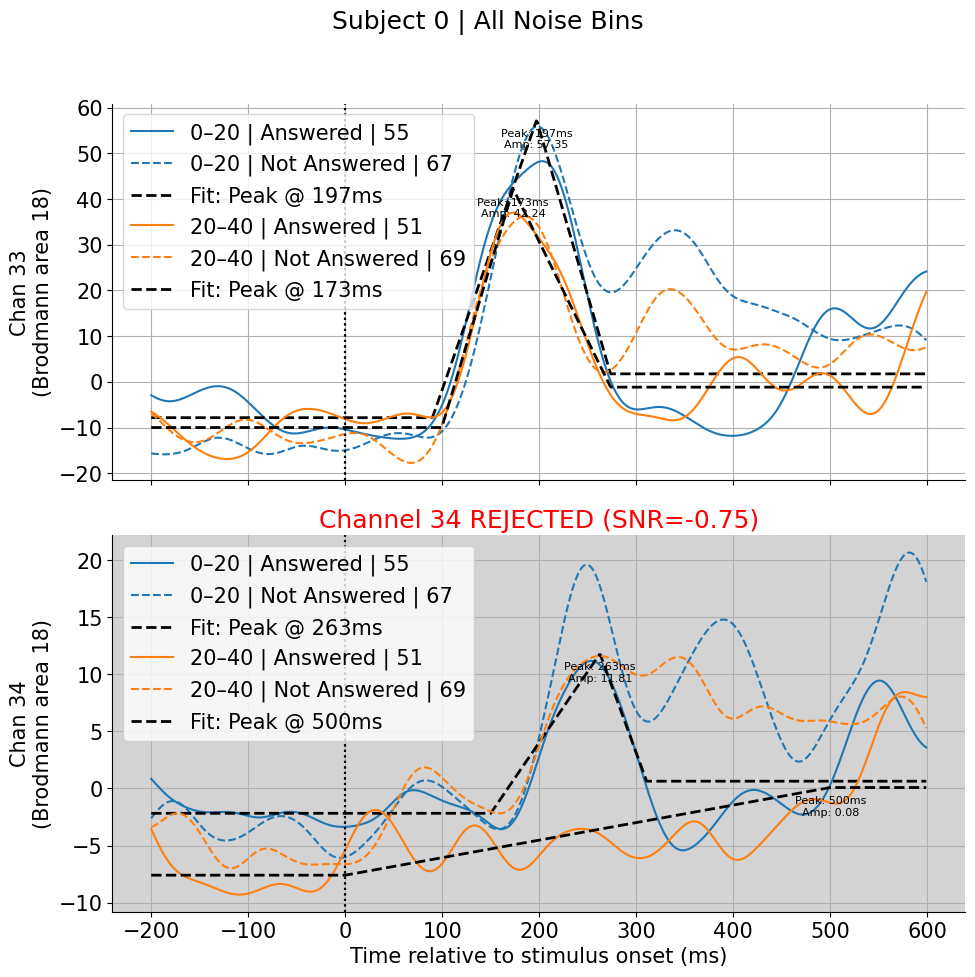

Electrodes active in face : [17 20 23 24 46]
          
Electodes active in house : [20 21]
          
Electodes exclusive to face : [17 23 24 46]
          
Brodmann Areas : ['Brodmann area 19' 'Brodmann area 37' 'Brodmann area 37']



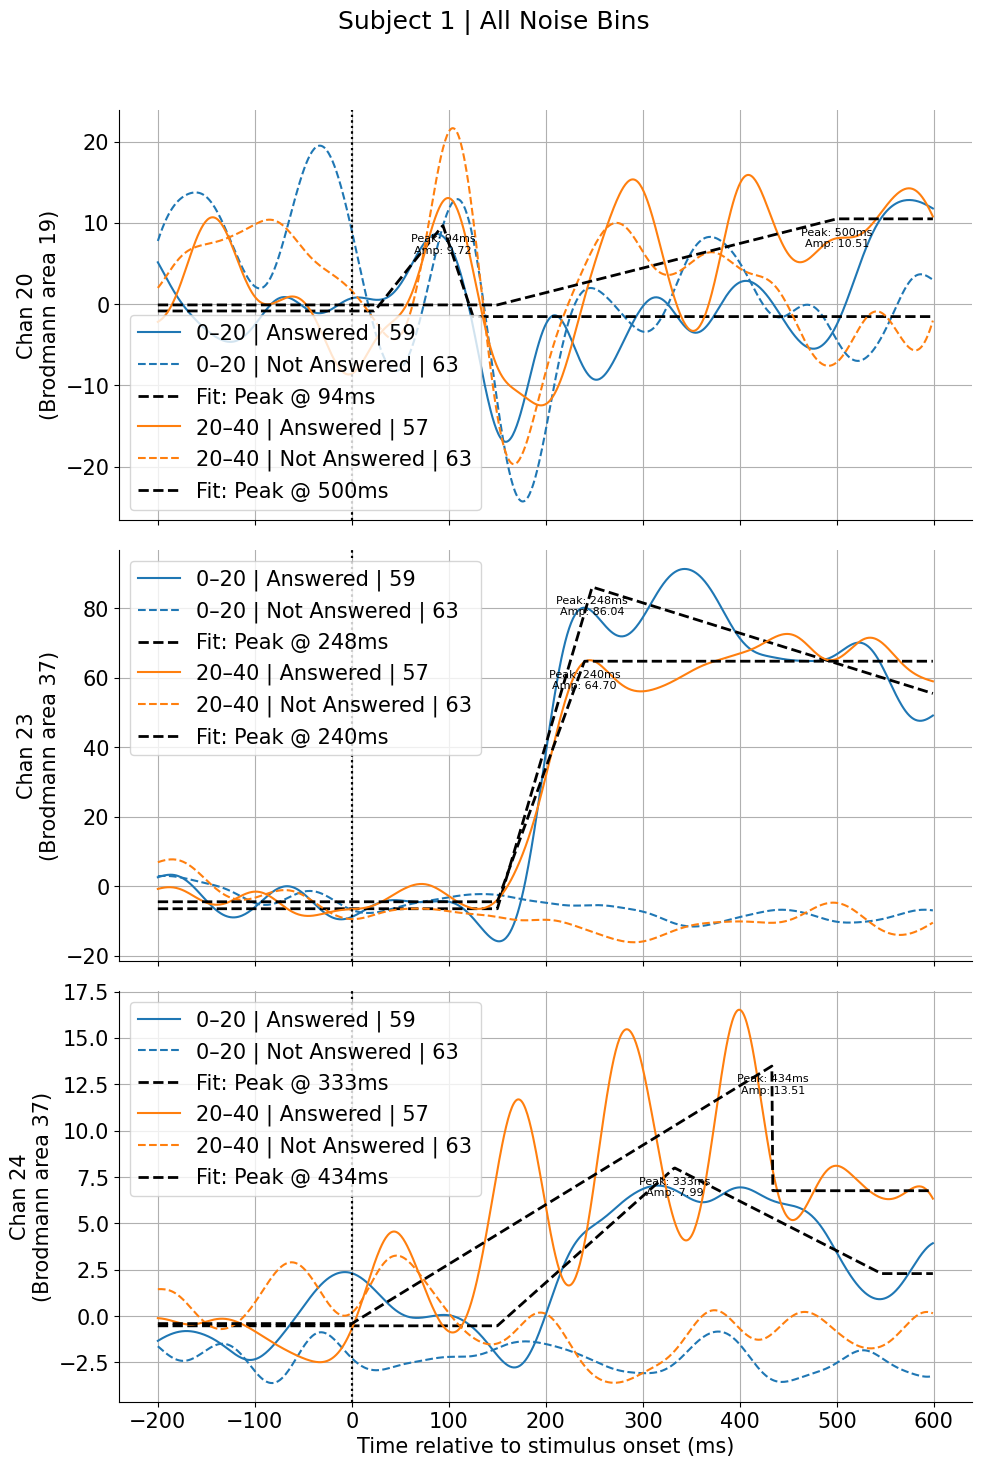

Electrodes active in face : [14 15]
          
Electodes active in house : [14]
          
Electodes exclusive to face : [15]
          
Brodmann Areas : ['Brodmann area 19' 'Brodmann area 19']



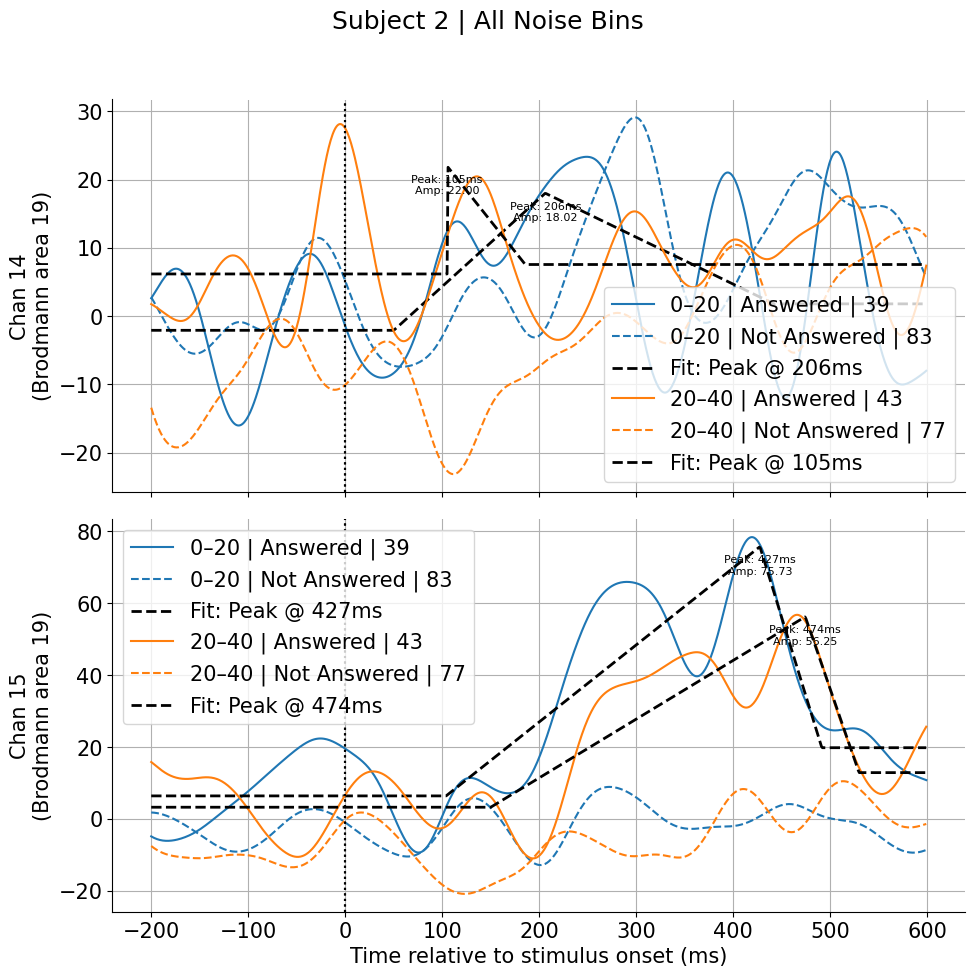

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from scipy.signal import savgol_filter

noise_bins = [0, 20, 40]
noise_bin_labels = [f"{noise_bins[i]}–{noise_bins[i+1]}" for i in range(len(noise_bins)-1)]
num_bins = len(noise_bin_labels)
colors = get_cmap("tab10").colors  # color palette for different bins

for subj_idx, subject in enumerate(subjects2_kept):

    # Selecting and displaying electrodes activated only when presented a face and not a house
    electrodes_indices = np.arange(len(all_active_electrodes_face[subj_idx]))
    exclusive_electrodes = all_active_electrodes_face[subj_idx] * (~all_active_electrodes_house[subj_idx])
    face_electrodes = electrodes_indices[all_active_electrodes_face[subj_idx]]

    selected_electrodes = []
    for chan in face_electrodes:
      if subject['Brodmann_Area'][chan] in ['Brodmann area 18', 'Brodmann area 19', 'Brodmann area 37']:
        selected_electrodes.append(chan)
    selected_electrodes = np.array(selected_electrodes)

    print(f"""Electrodes active in face : {electrodes_indices[all_active_electrodes_face[subj_idx]]}
          \nElectodes active in house : {electrodes_indices[all_active_electrodes_house[subj_idx]]}
          \nElectodes exclusive to face : {electrodes_indices[exclusive_electrodes]}
          \nBrodmann Areas : {np.array(subject['Brodmann_Area'])[selected_electrodes]}\n""")


    # Extracting electrode's signals
    V = subject['V'].astype('float32')[:, selected_electrodes] * subject['scale_uv'].astype('float32')[selected_electrodes]

    # High-pass filter at 50 Hz
    b, a = signal.butter(3, [50, 150], btype='band', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    # Compute power (rectification and squaring)
    V = np.abs(V)**2

    # Normalize over full signal (optional)
    """V /= np.mean(V, axis=0)"""
    V -= np.mean(V, axis=0)

    # Low-pass filter at 10 Hz
    b, a = signal.butter(3, [10], btype='low', fs=1000)
    V = signal.filtfilt(b, a, V, axis=0)

    nt, nchan = V.shape
    nstim = len(subject['t_on'])

    # Finding if the stimulus has been answered in a valid time interval
    answers = subject["key_press"].flatten()
    t_on_all = subject['t_on'].flatten()
    stim_noise_all = subject['stim_noise'].flatten()

    stimuli_answers = -np.ones_like(t_on_all, dtype=float)

    for k in range(len(t_on_all)):
        t_start = t_on_all[k] + 200
        t_end = t_on_all[k] + 1200
        valid_answers = answers[(answers > t_start) & (answers <= t_end)]
        if valid_answers.size > 0:
            this_answer = valid_answers[0]
            stimuli_answers[k] = this_answer - t_on_all[k]

    # Build epochs around each stimulus onset
    trange = np.arange(-200, 600)  # 800 ms window
    ts = subject['t_on'][:, np.newaxis] + trange
    V_epochs = V[ts, :]  # shape (nstim, len(trange), nchan)

    # === Plot all bins on the same figure for each channel ===
    fig, axs = plt.subplots(nchan, 1, figsize=(10, 5*nchan), sharex=True)
    if nchan == 1:
        axs = [axs]

    for j in range(num_bins):
        lower = noise_bins[j]
        upper = noise_bins[j+1]
        mask_noise = (stim_noise_all >= lower) & (stim_noise_all < upper)
        mask_resp = stimuli_answers != -1
        selected = mask_noise & mask_resp

        V_triggered = V_epochs[selected]
        V_not_triggered = V_epochs[mask_noise & (~mask_resp)]

                # Compute mean and std
        if selected.sum() > 1:
            V_triggered_mean = V_epochs[selected].mean(axis=0)
            V_triggered_std = V_epochs[selected].std(axis=0)
        else:
            V_triggered_mean = V_epochs[selected].squeeze()
            V_triggered_std = np.zeros_like(V_triggered_mean)

        if (mask_noise & (~mask_resp)).sum() > 1:
            V_not_triggered_mean = V_epochs[mask_noise & (~mask_resp)].mean(axis=0)
            V_not_triggered_std = V_epochs[mask_noise & (~mask_resp)].std(axis=0)
        else:
            V_not_triggered_mean = V_epochs[mask_noise & (~mask_resp)].squeeze()
            V_not_triggered_std = np.zeros_like(V_not_triggered_mean)

        # Thresholds for rejecting noisy channels
        peak_amp_threshold = 0.3  # adjust this based on your signal amplitude
        snr_threshold = 2.0       # SNR = peak amplitude / std of pre-stimulus

        for ch in range(nchan):
            ax = axs[ch]

            # Compute z-score to exclude very noisy (flat or erratic) channels
            is_good_channel = True
            if np.std(V_triggered_mean[trange < 0, ch]) == 0:
                is_good_channel = False

            snr = np.max(V_triggered_mean[(trange > 0) & (trange < 500), ch]) / np.std(V_triggered_mean[trange < 0, ch])
            if snr < snr_threshold:
                is_good_channel = False

            if not is_good_channel:
                ax.set_facecolor("lightgrey")
                ax.set_title(f"Channel {selected_electrodes[ch]} REJECTED (SNR={snr:.2f})", color='red')

            # Mean curves
            ax.plot(trange, V_triggered_mean[:, ch],
                    label=f"{noise_bin_labels[j]} | Answered | {np.count_nonzero(selected)}",
                    color=colors[j])

            ax.plot(trange, V_not_triggered_mean[:, ch],
                    label=f"{noise_bin_labels[j]} | Not Answered | {np.count_nonzero(mask_noise & (~mask_resp))}",
                    color=colors[j], linestyle='dashed')

            # === Fit and plot the peak function ===
            fit_params = fit_peak_function(trange, V_triggered_mean[:, ch])
            if fit_params is not None:
                fit_curve = peak_function(trange, *fit_params)
                ax.plot(trange, fit_curve, color='black', linestyle='--', linewidth=2, label=f"Fit: Peak @ {fit_params[2]:.0f}ms")

                # Annotate main parameters
                ax.annotate(f"Peak: {fit_params[2]:.0f}ms\nAmp: {fit_params[3]:.2f}",
                            (fit_params[2], fit_params[3]),
                            textcoords="offset points", xytext=(0, -20), ha='center', fontsize=8, color='black')

            # Cosmetics
            ax.axvline(x=0, color='black', linestyle='dotted')
            ax.set_ylabel(f"Chan {electrodes_indices[selected_electrodes][ch]}\n({np.array(subject['Brodmann_Area'])[selected_electrodes[ch]]})")
            ax.grid(True)


    axs[-1].set_xlabel("Time relative to stimulus onset (ms)")
    for ax in axs:
        ax.legend()

    fig.suptitle(f"Subject {subj_idx} | All Noise Bins")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()